# 🍱 BentoML — Package, Batch, and Serve Models Like a Pro

> **What you'll learn:** what a model-serving framework adds on top of FastAPI; how to version models in BentoML's **model store**; how to write a **service class** with typed APIs (Pydantic, NumPy, pandas); how **adaptive batching** works — and how much it really helps, measured under concurrent load; `async` APIs; composing services into a preprocessing → model pipeline; running `bentoml serve` and calling it from Python and raw HTTP; building a **Bento** and turning it into a Docker image; and how BentoML compares with FastAPI, Ray Serve, Triton, and KServe. You'll also build an adaptive batcher from scratch with `asyncio`.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [FastAPI](01_FastAPI.ipynb) (Pydantic validation, uvicorn, p95 latency) · [Docker & CI/CD](02_Docker_and_CI_CD.ipynb) (images, containers, ports) |
| **Tested with** | Python 3.12 · bentoml 1.4 · scikit-learn 1.9 · sentence-transformers 6.0 · aiohttp 3.14 · Docker 28 (optional — container cells skip honestly without it) |
| **Interview relevance** | ⭐⭐ Medium-High — "how would you serve this model at scale?", dynamic batching trade-offs, throughput vs latency, model versioning and packaging, BentoML vs FastAPI vs Ray Serve vs Triton |

## 🤔 What Is BentoML?

Think of a busy restaurant kitchen.

- A **plain FastAPI app** is a cook who takes one order, cooks it, serves it, then takes the next order.
- **BentoML** is the whole kitchen system: a **pantry** with labelled, dated ingredients (the *model store*), a **recipe card** for each dish (the *service*), a **pass** where orders pile up for a moment so the cook can fry ten portions in one pan (*adaptive batching*), and a sealed **lunch box** (a *Bento* 🍱) that any other kitchen can reheat and get exactly the same meal (a Docker image).

A few words we'll use all the time:

| Term | Plain-English meaning |
|---|---|
| **Model serving** | Running a trained model behind a network API so other programs can get predictions |
| **Inference** | One prediction call: input in → model → output out |
| **Service** | A Python class whose methods become HTTP endpoints |
| **Throughput** | How many requests per second the service completes |
| **Latency** | How long one request takes; **p95** = 95% of requests are faster than this |
| **Batching** | Running the model once on many inputs instead of once per input |
| **Bento** | A versioned folder with your service code, references to its models, locked dependencies, and a generated Dockerfile |

```
 training code ──save_model──▶  Model Store   cancer_rf:v1, cancer_rf:v2 (+ metadata, labels)
                                    │  BentoModel("cancer_rf:latest")
                                    ▼
 service.py    @bentoml.service class  ──  @bentoml.api methods (typed, optionally batchable)
                                    │  bentoml serve  → local HTTP server (development)
                                    │  bentoml build  → Bento (code + model refs + locked deps + Dockerfile)
                                    ▼
                  bentoml containerize → Docker image → Kubernetes / BentoCloud / any container host
```

## 🎯 Why It Matters

- **Serving is where models create value — and cost.** Training happens once; inference runs millions of times. Most of an ML team's compute bill is often serving.
- **Hardware is cheapest when it is busy.** CPUs and especially GPUs do far more work per second on a batch than on single items. Batching incoming requests is the single most important serving optimization, and every serious framework has it (BentoML's adaptive batching, Triton's dynamic batcher, Ray Serve's `@serve.batch`, vLLM's continuous batching).
- **Reproducible packaging.** "It works on my laptop" is not a deployment. A Bento pins the model version *and* every Python dependency, so the container runs the exact same thing everywhere.
- **In interviews** you'll get ML system-design prompts like *"serve this model at 1,000 requests/second with p95 under 100 ms"*. Interviewers expect you to talk about batching (and its latency cost), worker processes, model versioning, health checks, containerization, and when to reach for BentoML, Ray Serve, Triton, or KServe. This notebook gives you *measured* numbers to back those answers.

## ✅ By the End You Can

- [ ] Explain what a serving framework adds on top of FastAPI: batching, model store, packaging, composition, worker/resource config
- [ ] Save, version, and load models with BentoML's model store
- [ ] Write a service class with typed APIs (Pydantic, NumPy, pandas), serve it, and call it from Python and raw HTTP
- [ ] Configure adaptive batching and **measure** its throughput and latency effect under concurrent load
- [ ] Compose services with `bentoml.depends`, build a Bento, and containerize it
- [ ] Implement an adaptive micro-batcher from scratch with `asyncio.Queue`

## 📋 Table of Contents

1. [From FastAPI to a Serving Framework](#1.-From-FastAPI-to-a-Serving-Framework-🟢)
2. [The Model Store: Save, Version, Load](#2.-The-Model-Store:-Save,-Version,-Load-🟢)
3. [Your First Service: A Class with Typed APIs](#3.-Your-First-Service:-A-Class-with-Typed-APIs-🟢)
4. [Serving It: bentoml serve, Python Clients, and Raw HTTP](#4.-Serving-It:-bentoml-serve,-Python-Clients,-and-Raw-HTTP-🟡)
5. [Workers, Threads, Timeouts, and Resources](#5.-Workers,-Threads,-Timeouts,-and-Resources-🟡)
6. [Adaptive Batching, Measured](#6.-Adaptive-Batching,-Measured-🔴)
7. [Async APIs](#7.-Async-APIs-🟡)
8. [Composing Services with bentoml.depends](#8.-Composing-Services-with-bentoml.depends-🟡)
9. [Building a Bento](#9.-Building-a-Bento-🟡)
10. [Containerize and Run with Docker](#10.-Containerize-and-Run-with-Docker-🔴)
11. [Deployment Options: BentoCloud and Kubernetes](#11.-Deployment-Options:-BentoCloud-and-Kubernetes-🟢)
12. [BentoML vs FastAPI vs Ray Serve vs Triton vs KServe](#12.-BentoML-vs-FastAPI-vs-Ray-Serve-vs-Triton-vs-KServe-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Batched-Sentence-Embedding-Service) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

What the setup cell does:

- **`BENTOML_HOME`** tells BentoML where to keep its **model store** and **bento store**. BentoML reads it when it is imported, so we set it *before* `import bentoml`. We point it at `_outputs/bentoml_home` (ignored by git) and empty it first, so every run starts from a clean, reproducible state. By default it would be `~/bentoml`.
- **`BENTOML_DO_NOT_TRACK=True`** opts out of BentoML's anonymous usage statistics.
- **`check()`** gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).
- **`BentoServer`** runs `bentoml serve ...` in a **background process** on a free port, waits until `/readyz` answers, and stops the whole process group when you call `.stop()` (or leave a `with` block). A notebook can't run a blocking server in the foreground, so this is how we talk to *real* servers over *real* HTTP.
- **`load_test()`** fires many requests at once with `aiohttp` and reports throughput (requests/s) and p50/p95/p99 latency.
- **`DOCKER_OK`** records whether a Docker daemon is running; the container cells skip with an honest message if it isn't.

> Timings in this notebook are **real measurements on your machine** (which may be busy with other work), so your numbers will differ. Every printed conclusion is computed from *your* numbers.

In [1]:
# %pip install -q "bentoml>=1.4,<1.5" "scikit-learn>=1.8" "sentence-transformers>=5" datasets aiohttp httpx pandas matplotlib pyyaml

import asyncio
import atexit
import importlib
import json
import os
import re
import shutil
import signal
import socket
import subprocess
import sys
import textwrap
import time
from pathlib import Path

# ── BentoML reads these at import time, so set them BEFORE `import bentoml` ─────────────
OUTPUT_DIR = Path("_outputs").resolve()                      # files we write go here (ignored by git)
BENTOML_HOME = OUTPUT_DIR / "bentoml_home"                   # model store + bento store live here
shutil.rmtree(BENTOML_HOME, ignore_errors=True)              # start empty so every run is reproducible
os.environ["BENTOML_HOME"] = str(BENTOML_HOME)
os.environ["BENTOML_DO_NOT_TRACK"] = "True"                  # opt out of anonymous usage statistics
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"             # quieter model downloads in the mini project
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import aiohttp
import bentoml
import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import yaml
from pydantic import BaseModel, Field, FiniteFloat, ValidationError
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_DIR = OUTPUT_DIR / "bento_project"                   # service files for `bentoml serve` / `bentoml build`
LOG_DIR = OUTPUT_DIR / "bentoml_logs"                        # server logs (open them when something fails)
for folder in (PROJECT_DIR, LOG_DIR):
    folder.mkdir(parents=True, exist_ok=True)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))                     # lets the notebook import the service files too

SEED = 42
rng = np.random.default_rng(SEED)
print(f"Python {sys.version.split()[0]} | bentoml {bentoml.__version__} | scikit-learn {sklearn.__version__} | "
      f"aiohttp {aiohttp.__version__} | CPU cores: {os.cpu_count()}")
print("BentoML home:", BENTOML_HOME.relative_to(Path.cwd()))


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    numeric = not isinstance(expected, (str, dict, set))
    if numeric:
        try:
            got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            numeric = False
    if numeric:
        if got_arr.shape != exp_arr.shape:
            raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
        ok = np.allclose(got_arr, exp_arr, rtol=1e-4, atol=1e-6)
    else:
        ok = got == expected
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


class Timer:
    """Usage: `with Timer() as t: ...` → `t.seconds` is the elapsed wall-clock time."""

    def __enter__(self):
        self.start = time.perf_counter()
        return self

    def __exit__(self, *exc_info):
        self.seconds = time.perf_counter() - self.start


def free_port():
    """Ask the OS for a port nobody is using (other notebooks may already use 3000 or 8000)."""
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]


_RUNNING_SERVERS = []


class BentoServer:
    """Run `bentoml serve <target>` in a background process group on a free port.

        srv = BentoServer("my_service:MyService").start()   ...   srv.stop()
        with BentoServer("my_service:MyService") as srv:  ...  srv.url
    """

    def __init__(self, target, cwd=PROJECT_DIR, env=None, ready_timeout=180):
        self.target, self.cwd, self.ready_timeout = target, Path(cwd), ready_timeout
        self.env = {**os.environ, **(env or {})}
        self.proc = None

    def start(self):
        self.port = free_port()
        self.url = f"http://127.0.0.1:{self.port}"
        self.log_path = LOG_DIR / f"{self.target.replace(':', '_')}_{self.port}.log"
        self._log = open(self.log_path, "w")
        cmd = [sys.executable, "-m", "bentoml", "serve", self.target, "--host", "127.0.0.1", "--port", str(self.port)]
        # start_new_session=True gives the server (and the worker processes it spawns) their own process group,
        # so stop() can terminate all of them together.
        self.proc = subprocess.Popen(cmd, cwd=self.cwd, env=self.env, stdout=self._log,
                                     stderr=subprocess.STDOUT, start_new_session=True)
        _RUNNING_SERVERS.append(self)
        started = time.perf_counter()
        while True:
            if self.proc.poll() is not None:
                self.stop()
                raise RuntimeError(f"bentoml serve exited early:\n{self.log_tail()}")
            try:
                if httpx.get(f"{self.url}/readyz", timeout=1).status_code == 200:
                    break
            except httpx.HTTPError:
                pass
            if time.perf_counter() - started > self.ready_timeout:
                self.stop()
                raise TimeoutError(f"server not ready after {self.ready_timeout}s:\n{self.log_tail()}")
            time.sleep(0.3)
        self.startup_seconds = time.perf_counter() - started
        return self

    def stop(self):
        if self.proc is not None and self.proc.poll() is None:
            try:
                os.killpg(self.proc.pid, signal.SIGTERM)          # graceful, like pressing Ctrl+C
                self.proc.wait(timeout=30)
            except subprocess.TimeoutExpired:
                os.killpg(self.proc.pid, signal.SIGKILL)
                self.proc.wait()
            except ProcessLookupError:
                pass
        if self in _RUNNING_SERVERS:
            _RUNNING_SERVERS.remove(self)
        if hasattr(self, "_log") and not self._log.closed:
            self._log.close()

    def log_tail(self, n_chars=2000):
        return self.log_path.read_text()[-n_chars:] if self.log_path.exists() else ""

    def __enter__(self):
        return self.start()

    def __exit__(self, *exc_info):
        self.stop()


atexit.register(lambda: [srv.stop() for srv in list(_RUNNING_SERVERS)])   # never leave servers running


async def load_test(url, path, payloads, concurrency):
    """POST every JSON payload to url+path with `concurrency` requests in flight; return (stats, outputs)."""
    n = len(payloads)
    latencies_ms, statuses, outputs = [0.0] * n, [0] * n, [None] * n
    limiter = asyncio.Semaphore(concurrency)
    connector = aiohttp.TCPConnector(limit=concurrency)
    async with aiohttp.ClientSession(connector=connector, timeout=aiohttp.ClientTimeout(total=300)) as session:
        async def one(i):
            async with limiter:
                start = time.perf_counter()
                async with session.post(url + path, json=payloads[i]) as response:
                    body = await response.read()
                latencies_ms[i] = (time.perf_counter() - start) * 1000
                statuses[i] = response.status
                outputs[i] = json.loads(body) if response.status == 200 else None

        started = time.perf_counter()
        await asyncio.gather(*(one(i) for i in range(n)))
        wall = time.perf_counter() - started
    lat = np.array(latencies_ms)
    stats = {"path": path, "concurrency": concurrency, "requests": n, "rps": n / wall,
             "p50_ms": float(np.percentile(lat, 50)), "p95_ms": float(np.percentile(lat, 95)),
             "p99_ms": float(np.percentile(lat, 99)), "errors": int(sum(s != 200 for s in statuses))}
    return stats, outputs


def docker_status():
    """(True, server version) if a Docker daemon answers, else (False, reason)."""
    if shutil.which("docker") is None:
        return False, "the `docker` command is not installed"
    try:
        probe = subprocess.run(["docker", "info", "--format", "{{.ServerVersion}}"],
                               capture_output=True, text=True, timeout=30)
    except subprocess.TimeoutExpired:
        return False, "`docker info` timed out"
    if probe.returncode != 0:
        return False, "the Docker daemon is not running (start Docker Desktop)"
    return True, probe.stdout.strip()


DOCKER_OK, DOCKER_INFO = docker_status()
print("Docker:", f"✅ server {DOCKER_INFO}" if DOCKER_OK else f"⏭️ unavailable — {DOCKER_INFO}; container cells will skip")

Python 3.12.11 | bentoml 1.4.39 | scikit-learn 1.9.1 | aiohttp 3.14.3 | CPU cores: 15
BentoML home: _outputs/bentoml_home
Docker: ✅ server 28.5.2


## 1. From FastAPI to a Serving Framework 🟢

In the [FastAPI notebook](01_FastAPI.ipynb) you built a prediction API by hand. That works — but a production model service needs much more than routing and validation. Here is what you'd write yourself with FastAPI versus what BentoML gives you:

| Need | FastAPI alone | BentoML |
|---|---|---|
| Load the model once | lifespan event | the service class's `__init__` |
| Validate inputs | Pydantic | Pydantic **plus** NumPy / pandas / image / file types |
| Batch concurrent requests | write your own queue (you will, in 🔧 Build It From Scratch) | `@bentoml.api(batchable=True)` |
| Version models | your own folder or S3 naming scheme | **model store**: immutable `name:version` tags with metadata |
| Package for deployment | hand-written Dockerfile, pinned requirements | `bentoml build` locks dependencies and generates the Dockerfile; `bentoml containerize` builds the image |
| Multi-model pipelines | several apps + HTTP clients + retries | `bentoml.depends()`: each service runs in its own process(es) |
| Worker processes & resources | `uvicorn --workers N` | `workers=`, `threads=`, `resources=` on the decorator |
| Health checks & metrics | write the endpoints | `/livez`, `/readyz`, `/metrics` (Prometheus) built in |

Under the hood a BentoML service **is** an ASGI web app (Starlette) served by uvicorn worker processes — the same stack as FastAPI. BentoML adds the ML-specific layers on top.

**Why batching is the headline feature:** calling a model has a *fixed* cost per call (Python dispatch, input checks, looping over trees or layers) plus a *per-row* cost. Let's measure that split on a real model: a random forest that predicts whether a breast tumour is malignant from 30 measurements (569 real patients, UCI / scikit-learn dataset).

In [2]:
cancer = load_breast_cancer(as_frame=True)
FEATURES = list(cancer.feature_names)
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.25, stratify=cancer.target, random_state=SEED)
X_train_np, X_test_np = X_train.to_numpy(), X_test.to_numpy()
y_train_np, y_test_np = y_train.to_numpy(), y_test.to_numpy()

clf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=SEED))
clf.fit(X_train_np, y_train_np)            # fit on NumPy arrays: the service will receive NumPy arrays too
test_accuracy = clf.score(X_test_np, y_test_np)
print(f"{len(X_train)} train / {len(X_test)} test patients, {len(FEATURES)} features | test accuracy {test_accuracy:.3f}")
print("classes:", dict(enumerate(cancer.target_names)), "→ we report P(malignant) = predict_proba[:, 0]")

426 train / 143 test patients, 30 features | test accuracy 0.958
classes: {0: np.str_('malignant'), 1: np.str_('benign')} → we report P(malignant) = predict_proba[:, 0]


In [3]:
rows = X_test_np[:64]


def best_of(fn, repeats=5):
    """Run fn several times and keep the fastest run (the one least disturbed by other programs)."""
    times = []
    for _ in range(repeats):
        with Timer() as t:
            fn()
        times.append(t.seconds)
    return min(times)


one_at_a_time = best_of(lambda: [clf.predict_proba(rows[i:i + 1]) for i in range(len(rows))])
all_at_once = best_of(lambda: clf.predict_proba(rows))
per_row_single = one_at_a_time / len(rows) * 1000
per_row_batch = all_at_once / len(rows) * 1000
print(f"64 separate calls : {one_at_a_time * 1000:7.1f} ms total → {per_row_single:6.3f} ms per row")
print(f"1 call of 64 rows : {all_at_once * 1000:7.1f} ms total → {per_row_batch:6.3f} ms per row")
print(f"→ inside one call, each row is {per_row_single / per_row_batch:.0f}× cheaper: "
      f"{1 - all_at_once / one_at_a_time:.0%} of the one-at-a-time time was fixed per-call overhead")

64 separate calls :   229.6 ms total →  3.587 ms per row
1 call of 64 rows :     4.0 ms total →  0.062 ms per row
→ inside one call, each row is 58× cheaper: 98% of the one-at-a-time time was fixed per-call overhead


A web service receives requests **one at a time**, but many of them arrive at nearly the same moment. If the server waits a few milliseconds and runs them *together*, it pays the fixed overhead once instead of dozens of times. That is **adaptive batching**, and section 6 measures it on a real server.

> 💡 **Interview angle:** "Why not just use FastAPI?" — you can, for simple single-model APIs. A serving framework earns its place when you need **request batching**, **model versioning**, **reproducible packaging**, **multi-model pipelines**, and per-service **resource/worker configuration** without writing and maintaining that plumbing yourself.

## 2. The Model Store: Save, Version, Load 🟢

The **model store** is a local registry: a folder under `BENTOML_HOME/models/<name>/<version>/` holding the model files plus a `model.yaml` with metadata. Every save creates a new, **immutable** version with a generated tag like `cancer_rf:3k2x7vq...`. The alias **`latest`** always points to the newest one.

| API | What it does |
|---|---|
| `bentoml.sklearn.save_model(name, model, metadata=..., labels=...)` | save a scikit-learn model (there are also `bentoml.pytorch`, `bentoml.transformers`, `bentoml.xgboost`, …) |
| `bentoml.sklearn.load_model("name:latest")` | load it back into a Python object |
| `bentoml.models.get(tag)` / `bentoml.models.list(name)` | inspect stored versions (path, metadata, labels, creation time) |
| `with bentoml.models.create(name) as m:` | store **anything**: write your own files into `m.path` |
| `bentoml models list / export / import / push` (CLI) | the same from a terminal; export to a file or S3, push to BentoCloud |

- **metadata** = facts about the model (accuracy, training data, feature names).
- **labels** = short key/value tags for filtering (`owner`, `stage`).

We save a weak baseline first (version 1), then our real model (version 2).

In [4]:
baseline = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=10, max_depth=3, random_state=SEED))
baseline.fit(X_train_np, y_train_np)
baseline_accuracy = baseline.score(X_test_np, y_test_np)

v1 = bentoml.sklearn.save_model(
    "cancer_rf", baseline, labels={"owner": "ml-course", "stage": "baseline"},
    metadata={"test_accuracy": round(baseline_accuracy, 4), "n_estimators": 10, "feature_names": FEATURES})
v2 = bentoml.sklearn.save_model(
    "cancer_rf", clf, labels={"owner": "ml-course", "stage": "candidate"},
    metadata={"test_accuracy": round(test_accuracy, 4), "n_estimators": 200, "feature_names": FEATURES})

for stored in sorted(bentoml.models.list("cancer_rf"), key=lambda m: m.info.creation_time):
    print(f"{str(stored.tag):28s} accuracy={stored.info.metadata['test_accuracy']:.3f}  labels={stored.info.labels}")

latest = bentoml.models.get("cancer_rf:latest")
print("\ncancer_rf:latest →", latest.tag, "| is version 2:", latest.tag == v2.tag)
print("stored in:", Path(latest.path).relative_to(Path.cwd()), "→", sorted(p.name for p in Path(latest.path).iterdir()))

reloaded = bentoml.sklearn.load_model("cancer_rf:latest")
print("reloaded model gives identical predictions:",
      np.array_equal(reloaded.predict_proba(X_test_np), clf.predict_proba(X_test_np)))

cancer_rf:ziqxhsfp2wpo3iss   accuracy=0.944  labels={'owner': 'ml-course', 'stage': 'baseline'}
cancer_rf:zircgnvp2wpo3iss   accuracy=0.958  labels={'owner': 'ml-course', 'stage': 'candidate'}

cancer_rf:latest → cancer_rf:zircgnvp2wpo3iss | is version 2: True
stored in: _outputs/bentoml_home/models/cancer_rf/zircgnvp2wpo3iss → ['model.yaml', 'saved_model.pkl']


reloaded model gives identical predictions: True


`bentoml.models.create()` stores artifacts that aren't a framework model. Our pipeline in section 8 needs the **1st and 99th percentile of every feature** to clip extreme inputs. We compute them on the **training split only** (never the test set) and store them as a versioned JSON file.

In [5]:
p01, p99 = np.percentile(X_train_np, [1, 99], axis=0)
with bentoml.models.create("cancer_feature_stats", labels={"owner": "ml-course"},
                           metadata={"source": "train split", "percentiles": [1, 99]}) as stats_model:
    (Path(stats_model.path) / "stats.json").write_text(
        json.dumps({"columns": FEATURES, "p01": p01.tolist(), "p99": p99.tolist()}))

stats_stored = bentoml.models.get("cancer_feature_stats:latest")
print(stats_stored.tag, "→ files:", [p.name for p in Path(stats_stored.path).iterdir()],
      "| metadata:", stats_stored.info.metadata)

cancer_feature_stats:zivdcavp2wpo3iss → files: ['model.yaml', 'stats.json'] | metadata: {'source': 'train split', 'percentiles': [1, 99]}


### ✍️ Your Turn

Load **version 1** (the baseline) by its exact tag `v1.tag` — not `latest` — and compute its accuracy on the test set. It should match `baseline_accuracy`.

In [6]:
v1_accuracy = None  # TODO: load v1 from the store and score it on X_test_np, y_test_np
check("v1_accuracy", v1_accuracy, baseline_accuracy, hint="bentoml.sklearn.load_model(v1.tag).score(X_test_np, y_test_np)")

⏳ v1_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
v1_model = bentoml.sklearn.load_model(v1.tag)
v1_accuracy = v1_model.score(X_test_np, y_test_np)
check("v1_accuracy", v1_accuracy, baseline_accuracy)
```

Pinning an exact tag (instead of `latest`) is how you **roll back**: redeploy the service pointing at the old version.
</details>

> 💡 **Interview angle:** "How do you version models?" — every save gets an **immutable** tag plus metadata (metrics, data version, feature list); services reference a tag, so a deployment is reproducible and a rollback is just pointing at the previous tag. Mention that teams often keep MLflow as the registry of record and import into BentoML (`bentoml.mlflow.import_model`).

## 3. Your First Service: A Class with Typed APIs 🟢

A BentoML **service** is a Python class:

- `@bentoml.service(...)` on the class — service-level settings (workers, timeout, resources, container image).
- A class attribute `bentoml.models.BentoModel("cancer_rf:latest")` **declares** the model. Inside the service it resolves to the stored model; `bentoml build` uses it to package that exact version.
- `__init__` runs **once per worker process** → load the model there, never per request.
- Each `@bentoml.api` method becomes an HTTP `POST /<method_name>` endpoint. Its **type hints are the schema**: BentoML validates inputs with Pydantic and publishes an OpenAPI spec.

Supported input/output types include Python basics (`str`, `list[float]`, `dict`), **Pydantic models**, **`np.ndarray`** (optionally with `Shape` / `DType` validators), **`pd.DataFrame`**, images, and files.

`bentoml serve` needs the service in an importable **file**, so we write one to `_outputs/bento_project/cancer_service.py`. Read it carefully — every line is explained in the comments.

In [7]:
CANCER_SERVICE = '''"""Breast-cancer service: one model from the model store, three typed APIs."""
import os
from typing import Annotated

import bentoml
import numpy as np
import pandas as pd
from bentoml.exceptions import InvalidArgument
from bentoml.validators import DType, Shape
from pydantic import BaseModel, Field

N_FEATURES = 30

# What `bentoml build` installs in the container. Pin the library that pickled the model!
image = bentoml.images.Image(python_version="3.12").python_packages(
    "scikit-learn=={SKLEARN_VERSION}", "pandas", "numpy"
)


class Patient(BaseModel):
    features: list[float] = Field(min_length=N_FEATURES, max_length=N_FEATURES)
    threshold: float = Field(0.5, ge=0.0, le=1.0)


class Diagnosis(BaseModel):
    malignant_probability: float
    label: str
    model_version: str
    worker_pid: int


@bentoml.service(
    image=image,
    workers=int(os.environ.get("CANCER_WORKERS", "1")),   # worker processes; each loads its own model copy
    traffic={"timeout": 30},                               # seconds before a request is cancelled
    resources={"cpu": "1", "memory": "512Mi"},             # what ONE worker needs (used when deploying)
)
class CancerClassifier:
    model_ref = bentoml.models.BentoModel("cancer_rf:latest")   # declares the model → packaged by `bentoml build`

    def __init__(self) -> None:                                  # runs ONCE per worker process
        self.model = bentoml.sklearn.load_model(self.model_ref)
        self.version = str(self.model_ref.tag)
        self.feature_names = self.model_ref.info.metadata["feature_names"]

    @bentoml.api
    def predict_one(self, patient: Patient) -> Diagnosis:
        p = float(self.model.predict_proba(np.array([patient.features]))[0, 0])
        return Diagnosis(malignant_probability=round(p, 4), label="malignant" if p >= patient.threshold else "benign",
                         model_version=self.version, worker_pid=os.getpid())

    @bentoml.api
    def predict_array(self, features: Annotated[np.ndarray, Shape((-1, N_FEATURES)), DType("float64")]) -> np.ndarray:
        return self.model.predict_proba(features)[:, 0]

    @bentoml.api
    def predict_frame(self, patients: pd.DataFrame) -> list[float]:
        missing = [c for c in self.feature_names if c not in patients.columns]
        if missing:
            raise InvalidArgument(f"missing columns: {missing[:3]}")      # → HTTP 400 instead of a 500
        ordered = patients[self.feature_names].to_numpy(dtype=float)       # enforce the training column order
        return self.model.predict_proba(ordered)[:, 0].tolist()
'''.replace("{SKLEARN_VERSION}", sklearn.__version__)

(PROJECT_DIR / "cancer_service.py").write_text(CANCER_SERVICE)
importlib.invalidate_caches()
import cancer_service                                    # noqa: E402 — the file was just written
cancer_service = importlib.reload(cancer_service)        # pick up edits if you re-run this cell

Service = cancer_service.CancerClassifier
print("service:", Service.name, "| config:", Service.config)
for api_name, api in Service.apis.items():
    print(f"  POST /{api_name:14s} batchable={api.batchable}")

service: CancerClassifier | config: {'workers': 1, 'traffic': {'timeout': 30}, 'resources': {'cpu': '1', 'memory': '512Mi'}}
  POST /predict_array  batchable=False
  POST /predict_frame  batchable=False
  POST /predict_one    batchable=False


You can **instantiate the service class directly** in the notebook. No server, no HTTP — just the class with its model loaded. It's the quickest way to unit-test your logic before serving.

In [8]:
local_svc = Service()
print(local_svc.predict_one(cancer_service.Patient(features=X_test_np[0].tolist())))

local_probs = local_svc.predict_array(X_test_np[:5])
print("predict_array matches the model:", np.allclose(local_probs, clf.predict_proba(X_test_np[:5])[:, 0]))

try:
    cancer_service.Patient(features=[1.0, 2.0])
except ValidationError as err:
    print("Pydantic rejects bad input →", err.errors()[0]["msg"])

malignant_probability=0.01 label='benign' model_version='cancer_rf:zircgnvp2wpo3iss' worker_pid=42668
predict_array matches the model: True
Pydantic rejects bad input → List should have at least 30 items after validation, not 2


### ✍️ Your Turn

Clients don't always send DataFrame columns in training order. Call `local_svc.predict_frame` with the first 5 test rows **with the columns reversed** (`X_test.iloc[:5, ::-1]`). Because the API re-orders columns, the result should still equal `clf.predict_proba(X_test_np[:5])[:, 0]`.

In [9]:
shuffled_probs = None  # TODO: call local_svc.predict_frame(...) with reversed columns
check("column_order_safe", shuffled_probs, clf.predict_proba(X_test_np[:5])[:, 0],
      hint="local_svc.predict_frame(X_test.iloc[:5, ::-1])")

⏳ column_order_safe: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
shuffled_probs = local_svc.predict_frame(X_test.iloc[:5, ::-1])
check("column_order_safe", shuffled_probs, clf.predict_proba(X_test_np[:5])[:, 0])
```

If the API had used `patients.to_numpy()` directly, reversed columns would have silently produced **wrong** probabilities with no error. Selecting `patients[self.feature_names]` is cheap insurance.
</details>

> 💡 **Interview angle:** "Where do you load the model in a service?" — once per worker process at startup (`__init__` / lifespan), never inside the request handler. Then say *why*: loading means disk I/O and unpickling (we measure the cost in ⚠️ Common Pitfalls), and a readiness probe should only pass once the model is loaded.

## 4. Serving It: bentoml serve, Python Clients, and Raw HTTP 🟡

From a terminal you would run:

```bash
cd _outputs/bento_project
bentoml serve cancer_service:CancerClassifier            # http://localhost:3000 (default port)
bentoml serve cancer_service:CancerClassifier --reload   # development: restart when code changes
```

`module:ClassName` is the **import path** of the service. `bentoml serve` starts a supervisor process plus one process per worker. Every service automatically gets:

| Endpoint | Purpose |
|---|---|
| `POST /<api_name>` | your APIs; the JSON body's keys are the method's parameter names |
| `GET /livez` | **liveness**: the process is alive (restart it if this fails) |
| `GET /readyz` | **readiness**: the service finished `__init__` and can take traffic |
| `GET /metrics` | Prometheus metrics: request counts, latencies, batch sizes |
| `GET /docs.json` | OpenAPI schema (and a Swagger UI at `/`) |

Three ways to call it: **`bentoml.SyncHTTPClient`** (methods named like your APIs, keyword arguments), **`bentoml.AsyncHTTPClient`** (the same, for `asyncio`), or **raw HTTP** from any language.

In [10]:
cancer_server = BentoServer("cancer_service:CancerClassifier").start()
print(f"serving at {cancer_server.url} (ready after {cancer_server.startup_seconds:.1f}s) | log: {cancer_server.log_path.name}")

with bentoml.SyncHTTPClient(cancer_server.url) as client:
    diagnosis = client.predict_one(patient={"features": X_test_np[0].tolist(), "threshold": 0.5})
    served_array = client.predict_array(features=X_test_np[:5])
    served_frame = client.predict_frame(patients=X_test.iloc[:5])

print("predict_one   →", diagnosis)
print("predict_array →", served_array, type(served_array).__name__)
print("predict_frame →", served_frame)
print("all three agree with the local model:",
      np.allclose(served_array, clf.predict_proba(X_test_np[:5])[:, 0]) and np.allclose(served_frame, served_array)
      and np.isclose(diagnosis["malignant_probability"], served_array[0], atol=1e-4))

serving at http://127.0.0.1:62544 (ready after 2.1s) | log: cancer_service_CancerClassifier_62544.log
predict_one   → {'malignant_probability': 0.01, 'label': 'benign', 'model_version': 'cancer_rf:zircgnvp2wpo3iss', 'worker_pid': 42792}
predict_array → [0.01  1.    0.335 0.12  0.305] ndarray
predict_frame → [0.01, 1.0, 0.335, 0.12, 0.305]
all three agree with the local model: True


The Python client is a convenience. Underneath it's plain JSON over HTTP, which any language can send. Notice the status code for **invalid input: BentoML returns `400 Bad Request`** (FastAPI returns `422`). Clients should treat both as "fix your request, don't retry".

In [11]:
raw = httpx.post(f"{cancer_server.url}/predict_one", json={"patient": {"features": X_test_np[1].tolist()}})
print("valid request   :", raw.status_code, raw.json())

bad = httpx.post(f"{cancer_server.url}/predict_one", json={"patient": {"features": [1.0, 2.0]}})
print("too few features:", bad.status_code, bad.json()["detail"][0]["msg"])

bad_shape = httpx.post(f"{cancer_server.url}/predict_array", json={"features": [[1.0] * 5]})
print("wrong array shape:", bad_shape.status_code)

missing_cols = httpx.post(f"{cancer_server.url}/predict_frame", json={"patients": [{"mean radius": 14.0}]})
print("missing columns :", missing_cols.status_code, missing_cols.json())

print("livez / readyz  :", httpx.get(f"{cancer_server.url}/livez").status_code, httpx.get(f"{cancer_server.url}/readyz").status_code)
print("OpenAPI paths   :", sorted(httpx.get(f"{cancer_server.url}/docs.json").json()["paths"]))
metrics = httpx.get(f"{cancer_server.url}/metrics").text
print("a Prometheus metric line:", next(line for line in metrics.splitlines() if line.startswith("bentoml_service_request_total")))

valid request   : 200 {'malignant_probability': 1.0, 'label': 'malignant', 'model_version': 'cancer_rf:zircgnvp2wpo3iss', 'worker_pid': 42792}
too few features: 400 List should have at least 30 items after validation, not 2
wrong array shape: 400
missing columns : 400 [{'error': "missing columns: ['mean texture', 'mean perimeter', 'mean area']"}]
livez / readyz  : 200 200
OpenAPI paths   : ['/healthz', '/livez', '/metrics', '/predict_array', '/predict_frame', '/predict_one', '/readyz']
a Prometheus metric line: bentoml_service_request_total{endpoint="/predict_array",http_response_code="200",runner_name="CancerClassifier",service_name="CancerClassifier",service_version="not available"} 1.0


`AsyncHTTPClient` lets one Python process fire many requests concurrently with `asyncio.gather`. Jupyter already runs an event loop, so we can use top-level `await`.

In [12]:
async with bentoml.AsyncHTTPClient(cancer_server.url) as aclient:
    async_results = await asyncio.gather(*(aclient.predict_array(features=X_test_np[i:i + 1]) for i in range(8)))
print("8 concurrent calls →", np.round(np.concatenate(async_results), 3))
print("match the model:", np.allclose(np.concatenate(async_results), clf.predict_proba(X_test_np[:8])[:, 0]))

8 concurrent calls → [0.01  1.    0.335 0.12  0.305 1.    0.95  0.97 ]
match the model: True


### ✍️ Your Turn

Call `/predict_array` with **raw HTTP** (`httpx.post`) for the first 3 test rows and store the parsed JSON list in `raw_probs`. The body must be `{"features": <list of rows>}`.

In [13]:
raw_probs = None  # TODO: httpx.post(f"{cancer_server.url}/predict_array", json=...).json()
check("raw_http", raw_probs, clf.predict_proba(X_test_np[:3])[:, 0],
      hint='json={"features": X_test_np[:3].tolist()} — NumPy arrays must become lists to be JSON')

⏳ raw_http: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
response = httpx.post(f"{cancer_server.url}/predict_array", json={"features": X_test_np[:3].tolist()})
response.raise_for_status()
raw_probs = response.json()
check("raw_http", raw_probs, clf.predict_proba(X_test_np[:3])[:, 0])
```
</details>

In [14]:
cancer_server.stop()
print("server stopped:", cancer_server.proc.poll() is not None)

server stopped: True


> 💡 **Interview angle:** "Liveness vs readiness probe?" — liveness failing means *restart the container*; readiness failing means *stop sending it traffic* (e.g. still loading a 5 GB model). Pointing the liveness probe at a slow model-loading check causes restart loops.

## 5. Workers, Threads, Timeouts, and Resources 🟡

These settings on `@bentoml.service(...)` decide how much work one service can do at once:

| Setting | Meaning | Rule of thumb |
|---|---|---|
| `workers=N` (or `"cpu_count"`) | N **processes**, each with its own copy of the model | CPU-bound models: ≈ number of cores you can spare. Each worker costs a full model's RAM! |
| `threads=N` | how many **sync** (`def`) API calls may run at the same time inside one worker (default **1**) | raise it for I/O-bound or GIL-releasing code; `async def` APIs don't use this pool |
| `traffic={"timeout": s}` | cancel a request after `s` seconds | slightly above your worst healthy latency |
| `traffic={"max_concurrency": n}` | reject requests beyond `n` in flight | protects the service from overload (fail fast instead of queueing forever) |
| `resources={"cpu": "2", "memory": "4Gi", "gpu": 1}` | what one worker needs | used when **deploying** (e.g. BentoCloud picks machines from it); on your laptop it doesn't cap anything |

Our service reads `workers` from the `CANCER_WORKERS` environment variable (a common way to change settings without editing code). Let's measure 1 vs 2 workers under the same concurrent load. `Diagnosis.worker_pid` tells us which process answered each request.

In [15]:
print("CancerClassifier config:", Service.config, "| threads default:", Service.config.get("threads", 1))

patient_payloads = [{"patient": {"features": X_test_np[i % len(X_test_np)].tolist()}} for i in range(600)]
worker_rows = []
for n_workers in (1, 2):
    with BentoServer("cancer_service:CancerClassifier", env={"CANCER_WORKERS": str(n_workers)}) as srv:
        await load_test(srv.url, "/predict_one", patient_payloads[:64], concurrency=16)          # warm-up
        stats, outputs = await load_test(srv.url, "/predict_one", patient_payloads, concurrency=16)
    stats.update(workers=n_workers, startup_s=srv.startup_seconds,
                 distinct_pids=len({o["worker_pid"] for o in outputs if o is not None}))
    worker_rows.append(stats)

workers_df = pd.DataFrame(worker_rows).set_index("workers")[["startup_s", "rps", "p50_ms", "p95_ms", "errors", "distinct_pids"]]
display(workers_df.round(1))
gain = workers_df.loc[2, "rps"] / workers_df.loc[1, "rps"]
print(f"2 workers → {gain:.2f}× the throughput of 1 worker; requests were answered by "
      f"{workers_df.loc[2, 'distinct_pids']} different processes")
if gain < 1.3:
    print("   (less than the ideal 2×: other programs on this machine compete for the same cores)")

CancerClassifier config: {'workers': 1, 'traffic': {'timeout': 30}, 'resources': {'cpu': '1', 'memory': '512Mi'}} | threads default: 1


,startup_s,rps,p50_ms,p95_ms,errors,distinct_pids
workers,,,,,,
1,1.9,224.1,70.2,80.9,0,1
2,1.9,403.6,42.2,74.7,0,2


2 workers → 1.80× the throughput of 1 worker; requests were answered by 2 different processes


Two processes can use two CPU cores at once, so throughput rises for this CPU-bound model. **Memory** is the catch: every worker loads its own model copy. That's why large GPU models usually run with *one* worker per GPU and rely on **batching** (next section) instead.

> 💡 **Interview angle:** "Threads or processes for model inference in Python?" — CPU-bound Python code is limited by the GIL, so extra *threads* mostly help I/O-bound work or libraries that release the GIL (NumPy, PyTorch kernels); *processes* scale CPU work but multiply memory. Batching often beats both, because it makes each model call more efficient instead of just running more of them.

## 6. Adaptive Batching, Measured 🔴

With `@bentoml.api(batchable=True, ...)`, BentoML puts a **dispatcher** in front of your method:

```
 request A ─┐
 request B ─┼─▶ dispatcher queue ──(flush when the batch is big enough or waiting longer would break the latency budget)──▶ predict(A+B+C) ──▶ split ──▶ A, B, C
 request C ─┘
```

| Parameter | What it controls |
|---|---|
| `batchable=True` | turn batching on. Your method now receives the inputs of **many** requests stacked together |
| `batch_dim=0` | the axis along which inputs are stacked and outputs are split back (0 = rows). Use a tuple `(in_dim, out_dim)` if they differ |
| `max_batch_size=64` | the most items in one model call (bounded by memory, or by GPU memory) |
| `max_latency_ms=1000` | the latency budget, *including* waiting in the queue. Requests that can't be served in time get **HTTP 503** |

It is **adaptive** because the dispatcher keeps measuring how long batches of different sizes take, and decides how long it can afford to wait for more requests. Under light traffic it sends small batches right away; under heavy traffic batches grow.

> **Old-API warning:** tutorials written for BentoML ≤ 1.1 configure batching on "Runners" (`to_runner()`, `bentoml.Service`, a `runners:` block in a YAML config). In BentoML ≥ 1.2 the batching settings live **on the `@bentoml.api` decorator in your service code**, and runners are gone.

**Experiment:** the same model, served by the same process, behind two endpoints — `/predict_unbatched` and `/predict_batched`. Each request carries **one** patient. We send 600 requests at concurrency 1, 16, and 64. (The service file also contains two deliberately broken endpoints that we use later, in ⚠️ Common Pitfalls.)

In [16]:
BATCHING_SERVICE = '''"""Same model behind an unbatched and a batched endpoint (plus two deliberately broken ones for the pitfalls)."""
import bentoml
import numpy as np


@bentoml.service(workers=1, traffic={"timeout": 60})
class BatchingLab:
    model_ref = bentoml.models.BentoModel("cancer_rf:latest")

    def __init__(self) -> None:
        self.model = bentoml.sklearn.load_model(self.model_ref)

    @bentoml.api
    def predict_unbatched(self, features: np.ndarray) -> np.ndarray:
        return self.model.predict_proba(features)[:, 0]

    @bentoml.api(batchable=True, batch_dim=0, max_batch_size=64, max_latency_ms=1_000)
    def predict_batched(self, features: np.ndarray) -> np.ndarray:
        # `features` now holds rows from MANY requests stacked along axis 0 (batch_dim=0).
        # Return exactly one output row per input row so BentoML can split the result back per request.
        return self.model.predict_proba(features)[:, 0]

    @bentoml.api(batchable=True, batch_dim=0, max_batch_size=64, max_latency_ms=2)
    def predict_tight_latency(self, features: np.ndarray) -> np.ndarray:      # ⚠️ pitfall: budget below model latency
        return self.model.predict_proba(features)[:, 0]

    @bentoml.api(batchable=True, batch_dim=0, max_batch_size=64, max_latency_ms=1_000)
    def predict_wrong_batch_dim(self, features: np.ndarray) -> np.ndarray:    # ⚠️ pitfall: collapses the batch
        return self.model.predict_proba(features)[:, 0].mean(keepdims=True)
'''
(PROJECT_DIR / "batching_service.py").write_text(BATCHING_SERVICE)

N_REQUESTS = 600
row_payloads = [{"features": X_test_np[[i % len(X_test_np)]].tolist()} for i in range(N_REQUESTS)]   # 1 row each
test_probs = clf.predict_proba(X_test_np)[:, 0]
expected_per_request = np.array([test_probs[i % len(X_test_np)] for i in range(N_REQUESTS)])

def batch_counters(url, method):
    """(items, batches) processed so far by one batchable API, from the batch-size histogram in /metrics."""
    totals = {"sum": 0.0, "count": 0.0}
    for line in httpx.get(f"{url}/metrics").text.splitlines():
        if line.startswith("bentoml_service_adaptive_batch_size_") and f'method_name="{method}"' in line:
            kind = line.split("{")[0].rsplit("_", 1)[1]
            if kind in totals:
                totals[kind] += float(line.rsplit(" ", 1)[1])
    return totals["sum"], totals["count"]


batch_rows, served_outputs = [], {}
with BentoServer("batching_service:BatchingLab") as lab:
    for path in ("/predict_unbatched", "/predict_batched"):
        await load_test(lab.url, path, row_payloads[:100], concurrency=16)   # warm-up: the dispatcher calibrates itself
        for concurrency in (1, 16, 64):
            n = 150 if concurrency == 1 else N_REQUESTS
            items_before, batches_before = batch_counters(lab.url, "predict_batched")
            stats, outputs = await load_test(lab.url, path, row_payloads[:n], concurrency)
            items_after, batches_after = batch_counters(lab.url, "predict_batched")
            # rows per model call during THIS run (the unbatched endpoint always runs 1 row per call)
            stats["mean_batch"] = ((items_after - items_before) / (batches_after - batches_before)
                                   if path == "/predict_batched" else 1.0)
            batch_rows.append(stats)
            served_outputs[(path, concurrency)] = outputs
    metrics_text = httpx.get(f"{lab.url}/metrics").text

batch_df = pd.DataFrame(batch_rows)
display(batch_df.round(1))

,path,concurrency,requests,rps,p50_ms,p95_ms,p99_ms,errors,mean_batch
0,/predict_unbatched,1,150,227.2,4.1,5.8,6.5,0,1.0
1,/predict_unbatched,16,600,240.0,66.4,67.9,68.6,0,1.0
2,/predict_unbatched,64,600,232.4,269.8,280.9,291.5,0,1.0
3,/predict_batched,1,150,237.7,4.1,4.9,5.7,0,1.0
4,/predict_batched,16,600,1186.6,13.5,17.6,17.7,0,7.8
5,/predict_batched,64,600,2084.4,25.5,57.7,69.8,0,28.6


First, **correctness**: batching must never mix up whose answer is whose. Every response is compared with the model's own prediction for the row that request sent.

In [17]:
for (path, concurrency), outputs in served_outputs.items():
    got = np.array([out[0] for out in outputs])
    assert np.allclose(got, expected_per_request[:len(got)]), f"{path} @ {concurrency} returned wrong predictions"
print(f"✅ all {sum(len(o) for o in served_outputs.values())} responses match the model's prediction for their own row")

✅ all 2700 responses match the model's prediction for their own row


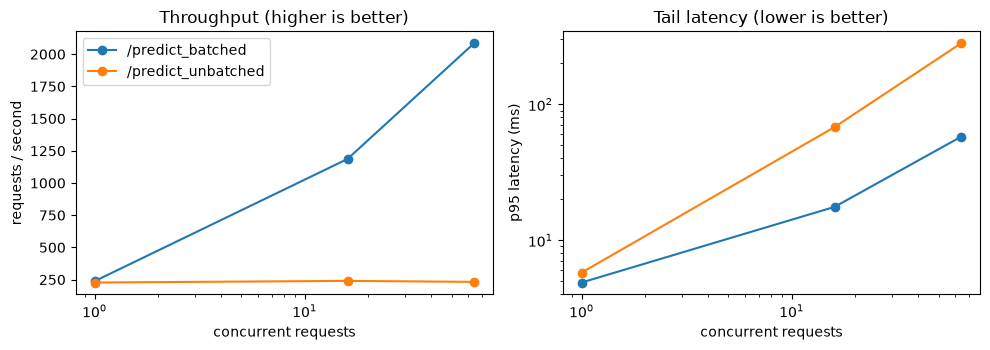

At 64 concurrent requests, batching gave 9.0× the throughput and 4.9× lower p95 latency.
At concurrency 1 (nobody to batch with), the batched endpoint's median latency changed by -0.1 ms.
Rows per model call on /predict_batched by concurrency: {1: 1.0, 16: 7.8, 64: 28.6}


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for path, group in batch_df.groupby("path"):
    axes[0].plot(group["concurrency"], group["rps"], marker="o", label=path)
    axes[1].plot(group["concurrency"], group["p95_ms"], marker="o", label=path)
axes[0].set(xscale="log", xlabel="concurrent requests", ylabel="requests / second", title="Throughput (higher is better)")
axes[1].set(xscale="log", yscale="log", xlabel="concurrent requests", ylabel="p95 latency (ms)", title="Tail latency (lower is better)")
axes[0].legend()
plt.tight_layout()
plt.show()

pivot = batch_df.pivot(index="concurrency", columns="path", values=["rps", "p50_ms", "p95_ms"])
top = int(batch_df["concurrency"].max())
speedup = pivot.loc[top, ("rps", "/predict_batched")] / pivot.loc[top, ("rps", "/predict_unbatched")]
p95_gain = pivot.loc[top, ("p95_ms", "/predict_unbatched")] / pivot.loc[top, ("p95_ms", "/predict_batched")]
low_load_delta = pivot.loc[1, ("p50_ms", "/predict_batched")] - pivot.loc[1, ("p50_ms", "/predict_unbatched")]
batched_sizes = batch_df[batch_df["path"] == "/predict_batched"].set_index("concurrency")["mean_batch"]
print(f"At {top} concurrent requests, batching gave {speedup:.1f}× the throughput and {p95_gain:.1f}× lower p95 latency.")
print(f"At concurrency 1 (nobody to batch with), the batched endpoint's median latency changed by {low_load_delta:+.1f} ms.")
print("Rows per model call on /predict_batched by concurrency:", {int(c): round(b, 1) for c, b in batched_sizes.items()})

How did we know the batch sizes? BentoML records a histogram of batch sizes in `/metrics` (`bentoml_service_adaptive_batch_size`). A Prometheus histogram has a `_sum` line (total items) and a `_count` line (number of batches), so the average batch size is sum ÷ count. `batch_counters()` above read those two numbers before and after each run.

### ✍️ Your Turn

Parse this sample of metrics text and compute the average batch size (`sum / count`).

In [19]:
sample_metrics = """# HELP bentoml_service_adaptive_batch_size Batch size of adaptive batching
bentoml_service_adaptive_batch_size_sum{method_name="embed",service_name="Demo",worker_index="1"} 1200.0
bentoml_service_adaptive_batch_size_count{method_name="embed",service_name="Demo",worker_index="1"} 48.0"""
avg_batch = None  # TODO: find the _sum and _count lines and divide
check("avg_batch", avg_batch, 25.0, hint="The value is the last space-separated token of each line: float(line.rsplit(' ', 1)[1])")

⏳ avg_batch: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sample_metrics = """# HELP bentoml_service_adaptive_batch_size Batch size of adaptive batching
bentoml_service_adaptive_batch_size_sum{method_name="embed",service_name="Demo",worker_index="1"} 1200.0
bentoml_service_adaptive_batch_size_count{method_name="embed",service_name="Demo",worker_index="1"} 48.0"""
values = {}
for line in sample_metrics.splitlines():
    if line.startswith("bentoml_service_adaptive_batch_size_"):
        metric_name = line.split("{")[0].rsplit("_", 1)[1]          # "sum" or "count"
        values[metric_name] = float(line.rsplit(" ", 1)[1])
avg_batch = values["sum"] / values["count"]
check("avg_batch", avg_batch, 25.0)
```
</details>

In [20]:
def mean_batch_size(text, method):
    """Average adaptive batch size for one API method, from Prometheus text."""
    values = {}
    for line in text.splitlines():
        if line.startswith("bentoml_service_adaptive_batch_size_") and f'method_name="{method}"' in line:
            kind = line.split("{")[0].rsplit("_", 1)[1]
            if kind in ("sum", "count"):
                values[kind] = values.get(kind, 0.0) + float(line.rsplit(" ", 1)[1])
    return values["sum"] / values["count"] if values.get("count") else float("nan")


avg_rows = mean_batch_size(metrics_text, "predict_batched")
print(f"over the whole server lifetime (all load levels + warm-up): {avg_rows:.1f} rows per call; "
      f"at concurrency {top} alone: {batched_sizes.loc[top]:.1f}")

over the whole server lifetime (all load levels + warm-up): 5.5 rows per call; at concurrency 64 alone: 28.6


**What the numbers show:** at concurrency 1 there is nobody to batch with, so both endpoints behave about the same (batch size ≈ 1). As concurrency grows, the unbatched endpoint queues requests behind one-row model calls and its p95 explodes. The batched endpoint instead runs bigger batches (the `mean_batch` column), paying the fixed per-call overhead far less often. Batching isn't free, though: a request may wait a little for company, and every request in a batch finishes when the whole batch finishes.

> 💡 **Interview angle:** "Explain dynamic batching and its trade-off." — collect requests that arrive close together and run one model call; it raises **throughput** (hardware does more per call) and usually lowers **tail latency under load**, at the cost of a small **queueing delay** at low load. Tune `max_batch_size` from memory and a latency-vs-batch-size profile, and set the latency budget from your SLO.

## 7. Async APIs 🟡

An API method can be `def` or `async def`, and the choice changes *where* it runs:

| Method | Runs on | Good for | Danger |
|---|---|---|---|
| `def` | a thread pool of size `threads` (default 1) | CPU-bound model calls, blocking libraries | with `threads=1`, calls run one at a time |
| `async def` | the worker's **event loop** | `await`-ing I/O: another service, a database, an LLM API | any **blocking** call (`time.sleep`, a heavy `model.predict`) freezes **every** request in that worker |

This is the same rule you met in the FastAPI notebook, and it matters just as much here. Below is a tiny service with three ways to "wait 0.25 s" (standing in for a slow downstream call).

In [21]:
ASYNC_SERVICE = '''"""Three ways to wait inside an API — only two of them are safe."""
import asyncio
import time

import bentoml


@bentoml.service(workers=1, threads=4)            # threads: how many *sync* (def) calls may run at once
class LatencyLab:
    @bentoml.api
    async def wait_async(self, seconds: float) -> float:
        await asyncio.sleep(seconds)                   # ✅ yields to the event loop: other requests keep flowing
        return seconds

    @bentoml.api
    async def wait_blocking_in_async(self, seconds: float) -> float:
        time.sleep(seconds)                            # ❌ blocks the event loop: every request in this worker waits
        return seconds

    @bentoml.api
    def wait_sync(self, seconds: float) -> float:
        time.sleep(seconds)                            # runs in the thread pool (size = threads)
        return seconds
'''
(PROJECT_DIR / "async_service.py").write_text(ASYNC_SERVICE)
print("wrote", (PROJECT_DIR / "async_service.py").relative_to(Path.cwd()))

wrote _outputs/bento_project/async_service.py


### ✍️ Your Turn

**Predict before measuring.** We'll send **8 concurrent** requests that each wait **0.25 s**. Ignoring network overhead, how many seconds should the whole group take for each endpoint? (Hint: the thread pool has 4 threads.)

In [22]:
predicted_wall_s = None  # TODO: {"wait_async": ..., "wait_blocking_in_async": ..., "wait_sync": ...}
check("predicted_wall_s", predicted_wall_s, {"wait_async": 0.25, "wait_blocking_in_async": 2.0, "wait_sync": 0.5},
      hint="async: all 8 wait together · blocking: one after another · sync: 4 at a time → 2 rounds")

⏳ predicted_wall_s: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
predicted_wall_s = {"wait_async": 0.25, "wait_blocking_in_async": 8 * 0.25, "wait_sync": 2 * 0.25}
check("predicted_wall_s", predicted_wall_s, {"wait_async": 0.25, "wait_blocking_in_async": 2.0, "wait_sync": 0.5})
```

`asyncio.sleep` lets all 8 wait at once. `time.sleep` inside `async def` holds the single event loop, so the requests run one by one. The sync version runs in 4 threads: 8 requests take 2 rounds.
</details>

In [23]:
async def concurrent_wall_time(url, endpoint, n=8, seconds=0.25):
    async with bentoml.AsyncHTTPClient(url) as aclient:
        method = getattr(aclient, endpoint)
        await method(seconds=0.0)                                   # warm-up
        start = time.perf_counter()
        await asyncio.gather(*(method(seconds=seconds) for _ in range(n)))
        return time.perf_counter() - start


theory = {"wait_async": 0.25, "wait_blocking_in_async": 2.0, "wait_sync": 0.5}
with BentoServer("async_service:LatencyLab") as latency_srv:
    measured = {name: await concurrent_wall_time(latency_srv.url, name) for name in theory}

async_df = pd.DataFrame({"theory_s": theory, "measured_s": measured})
display(async_df.round(2))
blocked = measured["wait_blocking_in_async"] / measured["wait_async"]
print(f"Blocking inside async def made 8 requests take {blocked:.1f}× longer than awaiting properly.")

,theory_s,measured_s
wait_async,0.25,0.26
wait_blocking_in_async,2.00,2.11
wait_sync,0.50,0.51


Blocking inside async def made 8 requests take 8.3× longer than awaiting properly.


> 💡 **Interview angle:** "When would you make a model API `async`?" — when it mostly **waits**: calling another service, a vector database, or an LLM API. For CPU-heavy inference use `def` (a thread pool) or offload with `await asyncio.to_thread(...)`, or a blocked event loop will stall health checks and every other request.

## 8. Composing Services with bentoml.depends 🟡

Real systems are pipelines: validate → preprocess → model → postprocess. With `bentoml.depends(OtherService)` one service calls another **as if it were a local object**, but each service runs in **its own process(es)** with its own workers and resources. In a real deployment they can live on different machines (CPU preprocessing, GPU model).

```
  client ──HTTP──▶ CancerPipeline (entry service)
                       │  self.guard.prepare(...)   ← looks like a method call, is really an HTTP call to another process
                       ▼
                   FeatureGuard: checks columns, orders them, clips to training percentiles
```

- Call a dependency from sync code: `self.guard.prepare(patients=df)`.
- From `async def` code: `await self.guard.to_async.prepare(patients=df)`.
- `bentoml serve pipeline_service:CancerPipeline` starts the entry service **and** all its dependencies.

In [24]:
PIPELINE_SERVICE = '''"""Two services: FeatureGuard (preprocessing) → CancerPipeline (model), wired with bentoml.depends."""
import json
import os
from pathlib import Path

import bentoml
import numpy as np
import pandas as pd
from bentoml.exceptions import InvalidArgument


@bentoml.service(workers=1, resources={"cpu": "1"})
class FeatureGuard:
    stats_ref = bentoml.models.BentoModel("cancer_feature_stats:latest")   # a plain JSON artifact from the store

    def __init__(self) -> None:
        stats = json.loads((Path(self.stats_ref.path) / "stats.json").read_text())
        self.columns = stats["columns"]
        self.low, self.high = np.array(stats["p01"]), np.array(stats["p99"])

    @bentoml.api
    def prepare(self, patients: pd.DataFrame) -> np.ndarray:
        missing = [c for c in self.columns if c not in patients.columns]
        if missing:
            raise InvalidArgument(f"missing columns: {missing[:3]}")
        x = patients[self.columns].to_numpy(dtype=float)
        return np.clip(x, self.low, self.high)              # extreme values → training 1st/99th percentile

    @bentoml.api
    def pid(self) -> int:
        return os.getpid()


@bentoml.service(workers=1)
class CancerPipeline:
    guard = bentoml.depends(FeatureGuard)                    # a handle to the other service
    model_ref = bentoml.models.BentoModel("cancer_rf:latest")

    def __init__(self) -> None:
        self.model = bentoml.sklearn.load_model(self.model_ref)

    @bentoml.api
    def predict(self, patients: pd.DataFrame) -> dict:
        x = self.guard.prepare(patients=patients)            # sync call into the FeatureGuard process
        probs = self.model.predict_proba(x)[:, 0]
        return {"malignant_probability": probs.round(4).tolist(), "entry_pid": os.getpid(), "guard_pid": self.guard.pid()}

    @bentoml.api
    async def apredict(self, patients: pd.DataFrame) -> list[float]:
        x = await self.guard.to_async.prepare(patients=patients)   # async call: the event loop stays free while waiting
        return self.model.predict_proba(x)[:, 0].round(4).tolist()
'''
(PROJECT_DIR / "pipeline_service.py").write_text(PIPELINE_SERVICE)
importlib.invalidate_caches()
import pipeline_service                                  # noqa: E402
pipeline_service = importlib.reload(pipeline_service)
print("CancerPipeline depends on:", list(pipeline_service.CancerPipeline.dependencies))

stats = json.loads((Path(stats_stored.path) / "stats.json").read_text())
expected_pipeline = clf.predict_proba(np.clip(X_test_np[:5], stats["p01"], stats["p99"]))[:, 0]

CancerPipeline depends on: ['guard']


In [25]:
with BentoServer("pipeline_service:CancerPipeline") as pipe_srv:
    with bentoml.SyncHTTPClient(pipe_srv.url) as client:
        served = client.predict(patients=X_test.iloc[:5])
        served_async = client.apredict(patients=X_test.iloc[:5])
        outlier = X_test.iloc[[0]].copy()
        outlier["mean area"] = 1e6                                      # e.g. a unit mistake upstream
        outlier_prob = client.predict(patients=outlier)["malignant_probability"][0]
        timings_ms = []
        for _ in range(30):
            with Timer() as t:
                client.predict(patients=X_test.iloc[:1])
            timings_ms.append(t.seconds * 1000)
print(f"2 services ready after {pipe_srv.startup_seconds:.1f}s")
print("served probabilities :", served["malignant_probability"])
print("match clip → model   :", np.allclose(served["malignant_probability"], expected_pipeline, atol=1e-4),
      "| async endpoint agrees:", np.allclose(served_async, expected_pipeline, atol=1e-4))
print(f"entry PID {served['entry_pid']} vs FeatureGuard PID {served['guard_pid']} → separate processes: "
      f"{served['entry_pid'] != served['guard_pid']}")
raw_outlier_prob = clf.predict_proba(outlier[FEATURES].to_numpy())[0, 0]
print(f"'mean area' = 1e6 → forest P(malignant): {outlier_prob:.3f} clipped vs {raw_outlier_prob:.3f} unclipped")
if np.isclose(outlier_prob, raw_outlier_prob, atol=1e-3):
    print("   identical: a tree only compares a feature with split thresholds, so any huge value lands in the same leaf")
# Models that extrapolate (linear models, neural nets) are where clipping really matters:
linear = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train_np, y_train_np)
outlier_np = outlier[FEATURES].to_numpy()
lin_raw = linear.predict_proba(outlier_np)[0, 0]
lin_clipped = linear.predict_proba(np.clip(outlier_np, stats["p01"], stats["p99"]))[0, 0]
print(f"   a logistic regression says {lin_raw:.3f} unclipped vs {lin_clipped:.3f} clipped "
      f"(original row: {clf.predict_proba(X_test_np[:1])[0, 0]:.3f} from the forest)")
print(f"median end-to-end latency through both services: {np.median(timings_ms):.1f} ms")

2 services ready after 1.9s
served probabilities : [0.01, 1.0, 0.335, 0.12, 0.305]
match clip → model   : True | async endpoint agrees: True
entry PID 43391 vs FeatureGuard PID 43390 → separate processes: True
'mean area' = 1e6 → forest P(malignant): 0.145 clipped vs 0.145 unclipped
   identical: a tree only compares a feature with split thresholds, so any huge value lands in the same leaf
   a logistic regression says 1.000 unclipped vs 0.191 clipped (original row: 0.010 from the forest)
median end-to-end latency through both services: 6.7 ms


### ✍️ Your Turn

Service graphs can be tested **without any server**: instantiating `CancerPipeline()` in the notebook also creates a local `FeatureGuard` for its dependency. Call `predict` on the first 5 test rows and store the list of probabilities in `local_pipeline_probs`.

In [26]:
local_pipeline_probs = None  # TODO: pipeline_service.CancerPipeline().predict(patients=...)["malignant_probability"]
check("local_pipeline", local_pipeline_probs, expected_pipeline.round(4),
      hint='local = pipeline_service.CancerPipeline(); local.predict(patients=X_test.iloc[:5])["malignant_probability"]')

⏳ local_pipeline: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
local_pipeline = pipeline_service.CancerPipeline()
local_pipeline_probs = local_pipeline.predict(patients=X_test.iloc[:5])["malignant_probability"]
check("local_pipeline", local_pipeline_probs, expected_pipeline.round(4))
```

Only the sync `predict` works locally: `to_async` exists on the *remote* handle that BentoML creates when the services run as separate processes.
</details>

> 💡 **Interview angle:** "When would you split preprocessing and the model into separate services?" — when they need **different hardware or scaling** (CPU tokenization/feature work vs. a GPU model), are **shared** by several models, or change on different release cycles. The cost is an extra network hop (serialization plus a few ms) and one more thing that can fail, so don't split a pipeline that fits comfortably in one process.

## 9. Building a Bento 🟡

`bentoml build` turns a service into a **Bento**: a versioned, self-describing folder in the bento store. It:

1. copies the source files you `include`;
2. records every model the services declare with `BentoModel(...)` — the exact versions, not `latest`;
3. **locks** the Python dependencies (resolves every package to an exact version for Linux);
4. generates a **Dockerfile** and an OpenAPI schema;
5. gives the result a version tag such as `cancer_classifier:abc123...`.

Two places hold the build configuration:

| Where | What goes there |
|---|---|
| Python: `image = bentoml.images.Image(python_version=...).python_packages(...)` passed to `@bentoml.service(image=image)` | Python version, packages, system packages, extra build commands (the modern way, used in `cancer_service.py`) |
| `bentofile.yaml` next to the code | which service to build (`service:`), which files to `include`/`exclude`, `labels`; it can also list packages if you prefer YAML |

Batching settings are **not** build configuration: they live on `@bentoml.api` in the code.

In [27]:
(PROJECT_DIR / "bentofile.yaml").write_text(textwrap.dedent("""\
    service: "cancer_service:CancerClassifier"    # import path of the entry service
    include:
      - "cancer_service.py"                         # ship only the files this service needs
    labels:
      owner: ml-course
      project: breast-cancer
"""))


def run_cli(args, cwd=PROJECT_DIR, timeout=900):
    """Run `bentoml <args>` in a subprocess; return (returncode, combined output without colour codes, seconds)."""
    with Timer() as t:
        proc = subprocess.run([sys.executable, "-m", "bentoml", *args], cwd=cwd, capture_output=True, text=True,
                              timeout=timeout, env={**os.environ, "NO_COLOR": "1", "TERM": "dumb"})
    text = re.sub(r"\x1b\[[0-9;?]*[A-Za-z]", "", proc.stdout + proc.stderr)   # Jupyter kernels often force colours
    return proc.returncode, text, t.seconds


def built_tag(output):
    """The `name:version` printed by `bentoml build --output tag`."""
    match = re.search(r"__tag__:([a-z0-9][a-z0-9_.-]*:[a-z0-9][a-z0-9_.-]*)", output)
    return match.group(1) if match else None


code, output, seconds = run_cli(["build", ".", "--output", "tag"])
bento_tag = built_tag(output)
assert code == 0 and bento_tag, f"bentoml build failed:\n{output[-3000:]}"
bento = bentoml.bentos.get(bento_tag)

print(f"built {bento_tag} in {seconds:.1f}s")
print("entry service :", bento.info.entry_service, "| labels:", bento.info.labels)
print("models        :", [str(m.tag) for m in bento.info.all_models])
requirements = (Path(bento.path) / "env" / "python" / "requirements.txt").read_text().splitlines()
pinned = [r for r in requirements if "==" in r]
print(f"locked deps   : {len(pinned)} exact pins, e.g.",
      [r for r in pinned if r.split("==")[0] in ("bentoml", "scikit-learn", "numpy", "pandas")])
print("bento files   :", sorted(str(p.relative_to(bento.path)) for p in Path(bento.path).rglob("*") if p.is_file()))
dockerfile = (Path(bento.path) / "env" / "docker" / "Dockerfile").read_text().splitlines()
print("Dockerfile    :", [line for line in dockerfile if line.startswith("FROM")][:1])

built cancer_classifier:3oc7yqvp2wxdbiss in 0.8s
entry service : CancerClassifier | labels: {'owner': 'ml-course', 'project': 'breast-cancer'}
models        : ['cancer_rf:zircgnvp2wpo3iss']
locked deps   : 74 exact pins, e.g. ['bentoml==1.4.39', 'numpy==2.5.3', 'pandas==3.0.5', 'scikit-learn==1.9.1']
bento files   : ['README.md', 'apis/openapi.yaml', 'apis/schema.json', 'bento.yaml', 'env/docker/Dockerfile', 'env/docker/entrypoint.sh', 'env/python/requirements.in', 'env/python/requirements.txt', 'src/bentofile.yaml', 'src/cancer_service.py']
Dockerfile    : ['FROM python:3.12-slim AS base-container']


Two things to notice:

- The Bento **records** the model version (`cancer_rf:<version>`); the model files themselves are copied in when you `containerize` (or `push` to BentoCloud). That's why models must be declared with `BentoModel` — see ⚠️ Common Pitfalls.
- The build log said it locked packages for a Linux platform (containers run Linux even when you develop on macOS). Exact pins are what make "works on my machine" also work in production.

### ✍️ Your Turn

Which exact model versions did the Bento record? Store their tags as a list of strings in `packaged_models`. It should be exactly version 2 of `cancer_rf`.

In [28]:
packaged_models = None  # TODO: read them from bento.info.all_models
check("packaged_models", packaged_models, [str(v2.tag)], hint="[str(m.tag) for m in bento.info.all_models]")

⏳ packaged_models: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
packaged_models = [str(m.tag) for m in bento.info.all_models]
check("packaged_models", packaged_models, [str(v2.tag)])
```

`latest` was resolved to a concrete version at build time. If you save a v3 tomorrow, this Bento still serves v2 — reproducibility.
</details>

> 💡 **Interview angle:** "What exactly is in a Bento, and why not just a Docker image?" — source code + exact model references + locked dependencies + generated Dockerfile + API schema, in one versioned artifact. The Docker image is *built from* it, and the same Bento can also go to BentoCloud. It keeps the ML-specific facts (which model version, which API) next to the packaging.

## 10. Containerize and Run with Docker 🔴

`bentoml containerize <bento_tag>` runs a Docker build using the Bento's generated Dockerfile (base image `python:3.12-slim`, locked requirements, your code and models). The image serves on port **3000** inside the container. In a terminal:

```bash
bentoml containerize cancer_classifier:latest --image-tag cancer-classifier:v2
docker run --rm -p 3000:3000 cancer-classifier:v2
```

The first build downloads the base image and installs packages (a minute or more). Later builds reuse Docker's layer cache. The cells below skip with an honest message if Docker isn't running.

In [29]:
CONTAINER_BUILT = False
image_tag = f"cancer-classifier:{bento.tag.version}"
if not DOCKER_OK:
    print(f"⏭️ Skipped: needs a running Docker daemon ({DOCKER_INFO}). Start Docker Desktop and re-run this cell.")
else:
    code, output, seconds = run_cli(["containerize", bento_tag, "--image-tag", image_tag], timeout=1800)
    if code == 0:
        CONTAINER_BUILT = True
        size_bytes, arch = subprocess.run(["docker", "image", "inspect", image_tag, "--format", "{{.Size}} {{.Architecture}}"],
                                          capture_output=True, text=True, timeout=60).stdout.split()
        print(f"✅ built image {image_tag} in {seconds:.0f}s | {int(size_bytes) / 1e6:.0f} MB | {arch}")
    else:
        print(f"❌ containerize failed (exit {code}) — last lines of the build log:\n{output[-1500:]}")

✅ built image cancer-classifier:3oc7yqvp2wxdbiss in 1s | 363 MB | arm64


In [30]:
if not CONTAINER_BUILT:
    print("⏭️ Skipped: no image was built in the previous cell.")
else:
    host_port = free_port()
    container_id = subprocess.run(["docker", "run", "--rm", "-d", "-p", f"127.0.0.1:{host_port}:3000", image_tag],
                                  capture_output=True, text=True, timeout=120, check=True).stdout.strip()
    container_url = f"http://127.0.0.1:{host_port}"
    try:
        with Timer() as boot:
            for _ in range(240):
                try:
                    if httpx.get(f"{container_url}/readyz", timeout=1).status_code == 200:
                        break
                except httpx.HTTPError:
                    pass
                time.sleep(0.5)
        with bentoml.SyncHTTPClient(container_url) as client:
            container_probs = client.predict_array(features=X_test_np[:5])
        print(f"container ready after {boot.seconds:.1f}s → predictions {np.round(container_probs, 3)}")
        print("identical to the notebook's model:", np.allclose(container_probs, clf.predict_proba(X_test_np[:5])[:, 0]))
        logs = subprocess.run(["docker", "logs", container_id], capture_output=True, text=True, timeout=60)
        print("last container log line:", (logs.stdout + logs.stderr).strip().splitlines()[-1][:160])
    finally:
        subprocess.run(["docker", "stop", container_id], capture_output=True, text=True, timeout=120)
        print("container stopped")

container ready after 1.7s → predictions [0.01  1.    0.335 0.12  0.305]
identical to the notebook's model: True
last container log line: 2026-09-14T00:47:30+0000 [INFO] [:1] 172.17.0.1:57570 (scheme=http,method=POST,path=/predict_array,type=application/json,length=1225) (status=200,type=applicati


container stopped


> 💡 **Interview angle:** "How do you keep model containers small and fast to start?" — slim base image, only needed packages (CPU-only PyTorch wheels when there's no GPU), no training data in the image, layer ordering so dependency layers stay cached, and either bake the model in (simple, immutable) or pull it at startup from a registry (smaller image, slower cold start). Always pin the framework version that serialized the model.

## 11. Deployment Options: BentoCloud and Kubernetes 🟢

A Bento or its image can run almost anywhere. The main paths:

| Option | How | Good to know |
|---|---|---|
| **BentoCloud** (BentoML's managed platform) | `bentoml cloud login`, then `bentoml deploy .` (or `bentoml deploy <bento_tag> -n <name>`) | Paid service: autoscaling (including scale-to-zero), GPUs, and each service in a `depends` graph can scale separately. We can't run it here without an account. |
| **Kubernetes, yourself** | push the image to a registry, then a `Deployment` + `Service` + `HorizontalPodAutoscaler` | Point probes at `/livez` and `/readyz`. For a `bentoml.depends` graph, deploy each service separately and connect them with `bentoml.depends(url=...)`. |
| **Any container platform** | the same image on Cloud Run, ECS/Fargate, Azure Container Apps, a VM with Docker | The simplest path for a single service. |
| **KServe / Knative** | use the image as a custom predictor container | When your platform team already standardizes on KServe. |

We have no cluster here, so we *generate* a Kubernetes manifest from Python and check its structure. `kubectl apply -f` would deploy it.

In [31]:
k8s_image = f"registry.example.com/ml/{image_tag}"
labels = {"app": "cancer-classifier"}
manifest = [
    {"apiVersion": "apps/v1", "kind": "Deployment", "metadata": {"name": "cancer-classifier"},
     "spec": {"replicas": 2, "selector": {"matchLabels": labels},
              "template": {"metadata": {"labels": labels},
                           "spec": {"containers": [{
                               "name": "bento", "image": k8s_image, "ports": [{"containerPort": 3000}],
                               "resources": {"requests": {"cpu": "1", "memory": "512Mi"}, "limits": {"memory": "1Gi"}},
                               "livenessProbe": {"httpGet": {"path": "/livez", "port": 3000}, "periodSeconds": 10},
                               "readinessProbe": {"httpGet": {"path": "/readyz", "port": 3000}, "periodSeconds": 5}}]}}}},
    {"apiVersion": "v1", "kind": "Service", "metadata": {"name": "cancer-classifier"},
     "spec": {"selector": labels, "ports": [{"port": 80, "targetPort": 3000}]}},
    {"apiVersion": "autoscaling/v2", "kind": "HorizontalPodAutoscaler", "metadata": {"name": "cancer-classifier"},
     "spec": {"scaleTargetRef": {"apiVersion": "apps/v1", "kind": "Deployment", "name": "cancer-classifier"},
              "minReplicas": 2, "maxReplicas": 10,
              "metrics": [{"type": "Resource", "resource": {"name": "cpu", "target": {"type": "Utilization", "averageUtilization": 70}}}]}},
]
manifest_path = OUTPUT_DIR / "k8s_cancer_classifier.yaml"
manifest_path.write_text(yaml.safe_dump_all(manifest, sort_keys=False))

docs = list(yaml.safe_load_all(manifest_path.read_text()))
container = docs[0]["spec"]["template"]["spec"]["containers"][0]
print("kinds:", [d["kind"] for d in docs])
print("probes:", container["livenessProbe"]["httpGet"]["path"], "/", container["readinessProbe"]["httpGet"]["path"],
      "| requests:", container["resources"]["requests"])
print("wrote", manifest_path.relative_to(Path.cwd()))

kinds: ['Deployment', 'Service', 'HorizontalPodAutoscaler']
probes: /livez / /readyz | requests: {'cpu': '1', 'memory': '512Mi'}
wrote _outputs/k8s_cancer_classifier.yaml


> 💡 **Interview angle:** "How would you autoscale a model service on Kubernetes?" — CPU-based HPA is a start, but for batched or GPU models **CPU is a poor signal**. Scale on **in-flight requests / queue depth** or latency (custom metrics via Prometheus, or KEDA). Keep `minReplicas ≥ 2` for availability. Warm new replicas (model loaded) before readiness passes.

## 12. BentoML vs FastAPI vs Ray Serve vs Triton vs KServe 🟡

| | **FastAPI** | **BentoML** | **Ray Serve** | **NVIDIA Triton** | **KServe** |
|---|---|---|---|---|---|
| What it is | general Python web framework | Python-first model-serving framework + packaging | serving library on the Ray distributed runtime | high-performance C++ inference server | Kubernetes platform (CRDs) for model serving |
| Batching | build it yourself | adaptive batching per API | `@serve.batch` | dynamic batcher (`config.pbtxt`) | depends on the runtime (e.g. Triton inside) |
| Multi-model pipelines | manual HTTP calls | `bentoml.depends` | deployment handles, independent scaling | ensembles / Python backend | InferenceGraph |
| Scaling | uvicorn workers, K8s | workers; BentoCloud or K8s | replicas + autoscaling across a Ray cluster | model instances per GPU; K8s | Knative/HPA autoscaling, scale-to-zero |
| Packaging | your Dockerfile | Bento → `containerize` | your image + Ray cluster config | model repository folder | `InferenceService` YAML |
| Sweet spot | simple APIs, business logic | teams wanting batteries-included Python serving | complex Python pipelines, many models, LLM serving on Ray | max GPU throughput for TensorRT/ONNX/PyTorch models | orgs standardized on Kubernetes |

**A decision rule you can say in an interview:** start with the simplest thing that meets the SLO. FastAPI for a light model with little traffic. BentoML (or Ray Serve) when you need batching, versioned packaging, and multi-model graphs in Python. Triton when GPU throughput per dollar dominates and the model exports to TensorRT/ONNX. KServe when the platform is Kubernetes and many teams deploy models the same way. These tools combine: e.g. KServe running Triton, or BentoML calling a Triton server.

> 💡 **Interview angle:** "Why not Triton for everything?" — Triton is fastest when the model is a supported format and preprocessing is light; Python-heavy logic (tokenizers, business rules, calling other services) is easier in BentoML or Ray Serve. Many production systems put Python orchestration in front of a Triton/vLLM engine.

## 🔧 Build It From Scratch

Let's build the core of adaptive batching ourselves: a **micro-batcher** with `asyncio.Queue`.

```
 submit(row) ──put (row, future)──▶ asyncio.Queue ──▶ background task:
                                                         1. wait for the FIRST item (no busy loop)
                                                         2. keep taking items until max_batch_size OR max_wait_ms has passed
                                                         3. run the model ONCE on the stacked batch (in a thread, off the event loop)
                                                         4. give each caller its own row of the output via its future
 await future ◀────────────────────────────────────────────────────────
```

A **future** is a placeholder for a result that will arrive later: the caller `await`s it, and the batching task fills it in with `set_result`.

In [32]:
class MicroBatcher:
    """Adaptive-ish batching: flush when `max_batch_size` items are waiting or `max_wait_ms` has passed."""

    def __init__(self, predict_batch, max_batch_size=64, max_wait_ms=5.0):
        self.predict_batch = predict_batch
        self.max_batch_size = max_batch_size
        self.max_wait = max_wait_ms / 1000
        self.queue = asyncio.Queue()
        self.batch_sizes = []
        self._worker = None

    async def submit(self, row):
        if self._worker is None:
            self._worker = asyncio.create_task(self._run())
        future = asyncio.get_running_loop().create_future()
        await self.queue.put((row, future))
        return await future

    async def _run(self):
        loop = asyncio.get_running_loop()
        while True:
            row, future = await self.queue.get()                  # 1. sleep until a request arrives
            rows, futures = [row], [future]
            deadline = loop.time() + self.max_wait
            while len(rows) < self.max_batch_size:                # 2. collect more until full or out of time
                remaining = deadline - loop.time()
                if remaining <= 0:
                    break
                try:
                    row, future = await asyncio.wait_for(self.queue.get(), timeout=remaining)
                except TimeoutError:
                    break
                rows.append(row)
                futures.append(future)
            self.batch_sizes.append(len(rows))
            try:                                                   # 3. one model call, off the event loop
                outputs = await asyncio.to_thread(self.predict_batch, np.stack(rows))
                if len(outputs) != len(rows):
                    raise ValueError(f"model returned {len(outputs)} outputs for {len(rows)} inputs")
                for fut, out in zip(futures, outputs):             # 4. hand every caller its own answer
                    fut.set_result(out)
            except Exception as exc:                               # one bad batch must not hang its callers
                for fut in futures:
                    if not fut.done():
                        fut.set_exception(exc)

    async def close(self):
        if self._worker is not None:
            self._worker.cancel()
            try:
                await self._worker
            except asyncio.CancelledError:
                pass
            self._worker = None


model_lock = asyncio.Lock()


async def predict_unbatched(row):
    """Baseline: one model call per request, one call at a time (like a worker with threads=1)."""
    async with model_lock:
        return (await asyncio.to_thread(clf.predict_proba, row[None, :]))[0, 0]


async def drive(call, rows, concurrency):
    """Send every row through `call` with `concurrency` callers at once; return (stats, outputs)."""
    limiter = asyncio.Semaphore(concurrency)
    latencies, outputs = [0.0] * len(rows), [None] * len(rows)

    async def one(i):
        async with limiter:
            start = time.perf_counter()
            outputs[i] = await call(rows[i])
            latencies[i] = (time.perf_counter() - start) * 1000

    started = time.perf_counter()
    await asyncio.gather(*(one(i) for i in range(len(rows))))
    wall = time.perf_counter() - started
    lat = np.array(latencies)
    return {"rps": len(rows) / wall, "p50_ms": np.percentile(lat, 50), "p95_ms": np.percentile(lat, 95)}, np.array(outputs, dtype=float)


scratch_rows = [X_test_np[i % len(X_test_np)] for i in range(N_REQUESTS)]
scratch_results = {}
scratch_results["unbatched"], out_unbatched = await drive(predict_unbatched, scratch_rows, concurrency=64)

batcher = MicroBatcher(lambda batch: clf.predict_proba(batch)[:, 0], max_batch_size=64, max_wait_ms=5)
scratch_results["micro-batched"], out_batched = await drive(batcher.submit, scratch_rows, concurrency=64)
busy_sizes = list(batcher.batch_sizes)

batcher.batch_sizes.clear()
scratch_results["micro-batched @ concurrency 1"], out_quiet = await drive(batcher.submit, scratch_rows[:100], concurrency=1)
quiet_sizes = list(batcher.batch_sizes)
await batcher.close()

# The from-scratch batcher must give exactly the same answers as the model and as BentoML's batched endpoint
bentoml_batched = np.array([out[0] for out in served_outputs[("/predict_batched", 64)]])
assert np.allclose(out_batched, expected_per_request) and np.allclose(out_unbatched, expected_per_request)
assert np.allclose(out_batched, bentoml_batched) and np.allclose(out_quiet, expected_per_request[:100])
print("✅ micro-batched predictions == unbatched predictions == BentoML /predict_batched responses")

display(pd.DataFrame(scratch_results).T.round(2))
print(f"under load (64 concurrent): {len(busy_sizes)} model calls, mean batch {np.mean(busy_sizes):.1f}, max {max(busy_sizes)}")
print(f"quiet (1 at a time): mean batch {np.mean(quiet_sizes):.1f} — the {batcher.max_wait * 1000:.0f} ms wait expires, "
      f"so a lone request is never stuck waiting for company")
scratch_speedup = scratch_results["micro-batched"]["rps"] / scratch_results["unbatched"]["rps"]
print(f"→ our ~40-line batcher gave {scratch_speedup:.1f}× the throughput of one-call-per-request at concurrency 64")

✅ micro-batched predictions == unbatched predictions == BentoML /predict_batched responses


,rps,p50_ms,p95_ms
unbatched,302.38,210.36,212.61
micro-batched,13259.24,3.72,4.16
micro-batched @ concurrency 1,95.73,10.61,10.88


under load (64 concurrent): 10 model calls, mean batch 60.0, max 64
quiet (1 at a time): mean batch 1.0 — the 5 ms wait expires, so a lone request is never stuck waiting for company
→ our ~40-line batcher gave 43.8× the throughput of one-call-per-request at concurrency 64


Compared with this toy, production batchers add: **latency-aware waiting** (BentoML models how long batches of each size take instead of using a fixed wait), **per-request deadlines** (the 503s you'll see in Pitfalls), padding for variable-length inputs, several batches running in parallel, and metrics.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Loading the model inside the request handler

In [33]:
def predict_reloading(row):
    model = bentoml.sklearn.load_model("cancer_rf:latest")        # ❌ disk read + unpickle on EVERY request
    return model.predict_proba(row[None, :])[0, 0]


loaded_once = bentoml.sklearn.load_model("cancer_rf:latest")      # ✅ once, like in __init__


def predict_loaded(row):
    return loaded_once.predict_proba(row[None, :])[0, 0]


with Timer() as slow:
    slow_out = [predict_reloading(r) for r in X_test_np[:20]]
with Timer() as fast:
    fast_out = [predict_loaded(r) for r in X_test_np[:20]]
assert np.allclose(slow_out, fast_out)
print(f"❌ load per request: {slow.seconds / 20 * 1000:6.1f} ms per prediction")
print(f"✅ load once       : {fast.seconds / 20 * 1000:6.1f} ms per prediction → {slow.seconds / fast.seconds:.1f}× faster, same answers")

❌ load per request:   13.8 ms per prediction
✅ load once       :    3.3 ms per prediction → 4.2× faster, same answers


### ❌ Pitfall 2 — A batchable API that collapses the batch dimension

With `batchable=True`, your method receives rows from **many** requests. If it returns anything other than one output per input row (a mean, a single label, a sum), BentoML splits the wrong-shaped result back to the callers. They get **HTTP 200 with wrong answers**, and no error is raised anywhere.

In [34]:
pitfall_server = BentoServer("batching_service:BatchingLab").start()
check_rows = expected_per_request[:300]

wrong_stats, wrong_outputs = await load_test(pitfall_server.url, "/predict_wrong_batch_dim", row_payloads[:300], concurrency=32)
right_stats, right_outputs = await load_test(pitfall_server.url, "/predict_batched", row_payloads[:300], concurrency=32)


def n_correct(outputs, expected):
    return sum(1 for out, exp in zip(outputs, expected) if out is not None and len(out) == 1 and np.isclose(out[0], exp))


print(f"❌ returns a mean over the batch: HTTP errors {wrong_stats['errors']}/300, correct answers "
      f"{n_correct(wrong_outputs, check_rows)}/300 — e.g. {wrong_outputs[:4]}")
print(f"✅ one output per input row     : HTTP errors {right_stats['errors']}/300, correct answers "
      f"{n_correct(right_outputs, check_rows)}/300")

❌ returns a mean over the batch: HTTP errors 0/300, correct answers 9/300 — e.g. [[0.01], [0.4283870967741936], [], []]
✅ one output per input row     : HTTP errors 0/300, correct answers 300/300


### ❌ Pitfall 3 — A latency budget below the model's own latency

`max_latency_ms` includes queueing **and** the model call. One call of this forest takes several milliseconds, so a 2 ms budget can't be met, and the dispatcher rejects requests with **HTTP 503**.

In [35]:
tight_stats, _ = await load_test(pitfall_server.url, "/predict_tight_latency", row_payloads[:300], concurrency=32)
print(f"❌ max_latency_ms=2    : {tight_stats['errors']}/300 requests failed (HTTP 503)")
print(f"✅ max_latency_ms=1000 : {right_stats['errors']}/300 requests failed")

❌ max_latency_ms=2    : 210/300 requests failed (HTTP 503)
✅ max_latency_ms=1000 : 0/300 requests failed


### ❌ Pitfall 4 — Your load generator is the bottleneck

A load test measures the **client plus the server**. We point two async Python clients at the *same* batched endpoint with the *same* 600 requests at concurrency 64. On many machines `httpx.AsyncClient` adds a lot of client-side overhead at high concurrency, while `aiohttp` (used by our `load_test`) keeps up. Always sanity-check the load generator: compare clients, run it in a separate process or machine, or use a dedicated tool like Locust or k6.

In [36]:
async def httpx_load_test(url, path, payloads, concurrency):
    limiter = asyncio.Semaphore(concurrency)
    latencies = []
    async with httpx.AsyncClient(timeout=300, limits=httpx.Limits(max_connections=concurrency)) as session:
        async def one(payload):
            async with limiter:
                start = time.perf_counter()
                (await session.post(url + path, json=payload)).raise_for_status()
                latencies.append((time.perf_counter() - start) * 1000)

        started = time.perf_counter()
        await asyncio.gather(*(one(p) for p in payloads))
        wall = time.perf_counter() - started
    return {"rps": len(payloads) / wall, "p95_ms": float(np.percentile(latencies, 95))}


httpx_stats = await httpx_load_test(pitfall_server.url, "/predict_batched", row_payloads, concurrency=64)
aiohttp_stats, _ = await load_test(pitfall_server.url, "/predict_batched", row_payloads, concurrency=64)
pitfall_server.stop()

client_ratio = aiohttp_stats["rps"] / httpx_stats["rps"]
print(f"❌ httpx.AsyncClient : {httpx_stats['rps']:7.0f} req/s | p95 {httpx_stats['p95_ms']:7.1f} ms")
print(f"✅ aiohttp           : {aiohttp_stats['rps']:7.0f} req/s | p95 {aiohttp_stats['p95_ms']:7.1f} ms")
if client_ratio > 1.5:
    print(f"→ same server, same requests, {client_ratio:.1f}× different throughput: the CLIENT limited the httpx measurement")
else:
    print(f"→ on this run both clients measured similar throughput ({client_ratio:.1f}×) — still worth checking every time")

❌ httpx.AsyncClient :     184 req/s | p95   970.9 ms
✅ aiohttp           :    2045 req/s | p95    51.5 ms
→ same server, same requests, 11.1× different throughput: the CLIENT limited the httpx measurement


### ❌ Pitfall 5 — Trusting `latest` for a release

`BentoModel("cancer_rf:latest")` is resolved **when you build**. If someone saves a new version (say, an accidental retrain of the weak baseline), rebuilding the *unchanged* code silently ships a different model.

In [37]:
accidental = bentoml.sklearn.save_model("cancer_rf", baseline, labels={"stage": "accidental-retrain"},
                                        metadata={"test_accuracy": round(baseline_accuracy, 4), "feature_names": FEATURES})
code, output, _ = run_cli(["build", ".", "--output", "tag"])
rebuilt = bentoml.bentos.get(built_tag(output))
rebuilt_model_tag = rebuilt.info.all_models[0].tag
print(f"❌ same code, rebuilt today → packages {rebuilt_model_tag} "
      f"(test accuracy {bentoml.models.get(rebuilt_model_tag).info.metadata['test_accuracy']:.3f})")
print(f"   the release you tested       → packaged {bento.info.all_models[0].tag} (test accuracy {test_accuracy:.3f})")

# ✅ For releases, pin the exact version in code — or assert in CI that the packaged tag is the one you evaluated
pinned_ref = bentoml.models.BentoModel(f"cancer_rf:{v2.tag.version}")
print(f"✅ pinned reference: {pinned_ref.tag} | CI check passes for the tested bento: "
      f"{[str(m.tag) for m in bento.info.all_models] == [str(v2.tag)]}, for the rebuild: {str(rebuilt_model_tag) == str(v2.tag)}")

bentoml.bentos.delete(str(rebuilt.tag))                 # tidy up: remove the accidental bento and model version
bentoml.models.delete(str(accidental.tag))
print("cancer_rf:latest is back to", bentoml.models.get("cancer_rf:latest").tag)

❌ same code, rebuilt today → packages cancer_rf:4nv7klvp2wpo3iss (test accuracy 0.944)
   the release you tested       → packaged cancer_rf:zircgnvp2wpo3iss (test accuracy 0.958)
✅ pinned reference: cancer_rf:zircgnvp2wpo3iss | CI check passes for the tested bento: True, for the rebuild: False
cancer_rf:latest is back to cancer_rf:zircgnvp2wpo3iss


### ❌ Pitfall 6 — Loading a model by string tag in `__init__`: it isn't packaged

`bentoml.sklearn.load_model("cancer_rf:latest")` inside `__init__` works on your laptop, because the model is in your local store. But `bentoml build` only packages models **declared** as `BentoModel` class attributes. The container would start and then crash with "model not found".

In [38]:
nomodel_dir = OUTPUT_DIR / "bento_nomodel"
nomodel_dir.mkdir(exist_ok=True)
(nomodel_dir / "service.py").write_text(textwrap.dedent('''\
    import bentoml
    import numpy as np


    @bentoml.service
    class NoModelRef:
        def __init__(self) -> None:
            self.model = bentoml.sklearn.load_model("cancer_rf:latest")   # ❌ invisible to `bentoml build`

        @bentoml.api
        def predict(self, features: np.ndarray) -> np.ndarray:
            return self.model.predict_proba(features)[:, 0]
'''))
(nomodel_dir / "bentofile.yaml").write_text('service: "service:NoModelRef"\ninclude:\n  - "service.py"\n')

code, output, _ = run_cli(["build", ".", "--output", "tag"], cwd=nomodel_dir)
assert code == 0, output[-2000:]
nomodel_bento = bentoml.bentos.get(built_tag(output))
print(f"❌ string tag in __init__   → models packaged: {[str(m.tag) for m in nomodel_bento.info.all_models]}")
print(f"✅ BentoModel class attribute → models packaged: {[str(m.tag) for m in bento.info.all_models]}")

❌ string tag in __init__   → models packaged: []
✅ BentoModel class attribute → models packaged: ['cancer_rf:zircgnvp2wpo3iss']


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Summarize a load test
Given per-request latencies and the total wall-clock time, build `summary = {"rps": ..., "p50_ms": ..., "p95_ms": ...}` with NumPy's default percentile method.

In [39]:
latencies_ms = [12.0, 15.0, 11.0, 90.0, 14.0, 13.0, 16.0, 12.5, 13.5, 250.0]
wall_seconds = 0.5
summary = None  # TODO
check("load_summary", None if summary is None else [summary["rps"], summary["p50_ms"], summary["p95_ms"]],
      [20.0, 13.75, 178.0], hint="rps = len(latencies) / wall_seconds; np.percentile(latencies_ms, 50) and 95")

⏳ load_summary: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
latencies_ms = [12.0, 15.0, 11.0, 90.0, 14.0, 13.0, 16.0, 12.5, 13.5, 250.0]
wall_seconds = 0.5
summary = {"rps": len(latencies_ms) / wall_seconds,
           "p50_ms": float(np.percentile(latencies_ms, 50)),
           "p95_ms": float(np.percentile(latencies_ms, 95))}
check("load_summary", [summary["rps"], summary["p50_ms"], summary["p95_ms"]], [20.0, 13.75, 178.0])
```

The mean here is 44.7 ms, which describes *nobody's* experience. The median is 13.75 ms, while two unlucky users waited 90 and 250 ms. That's why SLOs use percentiles.
</details>

### 🟢 Exercise 2 — Version a model with metadata
Save `logreg` to the model store as `"cancer_logreg"` with `metadata={"n_train": <number of training rows>}`. Then read that number **back from the store** into `stored_n_train`.

In [40]:
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train_np, y_train_np)
stored_n_train = None  # TODO
check("store_metadata", stored_n_train, len(X_train_np),
      hint="bentoml.sklearn.save_model('cancer_logreg', logreg, metadata=...), then bentoml.models.get('cancer_logreg:latest').info.metadata")

⏳ store_metadata: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train_np, y_train_np)
bentoml.sklearn.save_model("cancer_logreg", logreg, metadata={"n_train": len(X_train_np)})
stored_n_train = bentoml.models.get("cancer_logreg:latest").info.metadata["n_train"]
check("store_metadata", stored_n_train, len(X_train_np))
```
</details>

### 🟢 Exercise 3 — Declare a batchable API
Define a service class `Doubler` with a **batchable** API `double(self, x: np.ndarray) -> np.ndarray` that returns `x * 2`, with `max_batch_size=32` and `max_latency_ms=100`. The checker reads the API config and calls the class locally.

In [41]:
Doubler = None  # TODO: replace with a @bentoml.service class
check("doubler", None if Doubler is None else
      [Doubler.apis["double"].batchable, Doubler.apis["double"].max_batch_size, *Doubler().double(np.array([1.0, 2.0]))],
      [True, 32, 2.0, 4.0], hint="@bentoml.service on the class, @bentoml.api(batchable=True, max_batch_size=32, max_latency_ms=100) on the method")

⏳ doubler: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@bentoml.service
class Doubler:
    @bentoml.api(batchable=True, max_batch_size=32, max_latency_ms=100)
    def double(self, x: np.ndarray) -> np.ndarray:
        return x * 2


check("doubler", [Doubler.apis["double"].batchable, Doubler.apis["double"].max_batch_size, *Doubler().double(np.array([1.0, 2.0]))],
      [True, 32, 2.0, 4.0])
```

`x * 2` is element-wise, so it keeps one output row per input row — safe to batch.
</details>

### 🟡 Exercise 4 — Simulate the batching window
Requests arrive at the times in `arrivals_ms` (sorted). The first request of a batch **opens a window**. A request joins the current batch if the batch has fewer than `max_batch_size` items **and** it arrives at or before `window_open + max_wait_ms`. Otherwise the batch is flushed and that request opens a new window. Write `simulate_batches(arrivals_ms, max_batch_size, max_wait_ms)` returning the list of batch sizes.

In [42]:
def simulate_batches(arrivals_ms, max_batch_size, max_wait_ms):
    return None  # TODO


check("batch_sizes", simulate_batches([0, 1, 2, 3, 4, 20, 21, 50, 51, 52, 53, 54, 55], max_batch_size=4, max_wait_ms=10),
      [4, 1, 2, 4, 2], hint="Track the current size and the time the window opened; flush when full or when t > opened + max_wait_ms.")

⏳ batch_sizes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def simulate_batches(arrivals_ms, max_batch_size, max_wait_ms):
    sizes, current, opened = [], 0, None
    for t in arrivals_ms:
        if current and (current == max_batch_size or t > opened + max_wait_ms):
            sizes.append(current)          # flush: batch full or window expired
            current = 0
        if current == 0:
            opened = t                     # this request opens a new window
        current += 1
    if current:
        sizes.append(current)
    return sizes


check("batch_sizes", simulate_batches([0, 1, 2, 3, 4, 20, 21, 50, 51, 52, 53, 54, 55], max_batch_size=4, max_wait_ms=10),
      [4, 1, 2, 4, 2])
```

The lone request at t=4 shows the trade-off: it waited for company that never came.
</details>

### 🟡 Exercise 5 — Validate requests with Pydantic
Write a Pydantic model `PatientRequest` with `features`: a list of **exactly 30 finite floats** (no NaN or infinity), and `threshold`: a float in **[0, 1]**, default 0.5. The checker tries one valid and three invalid payloads.

In [43]:
PatientRequest = None  # TODO: a pydantic BaseModel subclass


def accepts(model_cls, payload):
    try:
        model_cls(**payload)
        return True
    except ValidationError:
        return False


results = None if PatientRequest is None else (
    accepts(PatientRequest, {"features": X_test_np[0].tolist()}),
    not accepts(PatientRequest, {"features": [float("nan")] * 30}),
    not accepts(PatientRequest, {"features": [1.0] * 29}),
    not accepts(PatientRequest, {"features": X_test_np[0].tolist(), "threshold": 1.5}),
)
check("patient_request", results, (True, True, True, True),
      hint="list[FiniteFloat] with Field(min_length=30, max_length=30); threshold: float = Field(0.5, ge=0, le=1)")

⏳ patient_request: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class PatientRequest(BaseModel):
    features: list[FiniteFloat] = Field(min_length=30, max_length=30)
    threshold: float = Field(0.5, ge=0.0, le=1.0)


def accepts(model_cls, payload):
    try:
        model_cls(**payload)
        return True
    except ValidationError:
        return False


results = (
    accepts(PatientRequest, {"features": X_test_np[0].tolist()}),
    not accepts(PatientRequest, {"features": [float("nan")] * 30}),
    not accepts(PatientRequest, {"features": [1.0] * 29}),
    not accepts(PatientRequest, {"features": X_test_np[0].tolist(), "threshold": 1.5}),
)
check("patient_request", results, (True, True, True, True))
```

A NaN that slips through reaches the model, and many models turn it into a confident-looking but meaningless prediction. Validate at the edge.
</details>

### 🔴 Exercise 6 — Pick batching settings for an SLO (interview classic)
You profiled a model on one GPU: `batch_ms[b]` is how long one call with `b` items takes. The SLO is **p95 ≤ 40 ms**. Assume a request's worst-case latency is `max_wait_ms + batch_ms[b]`, and full batches give throughput `b / (batch_ms[b] / 1000)` requests/s.

With `max_wait_ms = 10`, find:
1. the batch size with the **highest throughput** that still meets the SLO,
2. that throughput as an integer (round to nearest),
3. the **largest `max_wait_ms`** you could afford with that batch size.

Store `(best_batch, best_rps, max_affordable_wait_ms)`.

In [44]:
batch_ms = {1: 6.0, 4: 6.5, 8: 7.2, 16: 8.8, 32: 12.5, 64: 20.0, 128: 36.0}
slo_ms, max_wait_ms = 40.0, 10.0
batching_plan = None  # TODO: (best_batch, best_rps, max_affordable_wait_ms)
check("batching_plan", batching_plan, (64, 3200, 20.0),
      hint="Keep sizes with max_wait_ms + batch_ms[b] <= slo_ms, maximize b / (batch_ms[b] / 1000); spare wait = slo_ms - batch_ms[best]")

⏳ batching_plan: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
batch_ms = {1: 6.0, 4: 6.5, 8: 7.2, 16: 8.8, 32: 12.5, 64: 20.0, 128: 36.0}
slo_ms, max_wait_ms = 40.0, 10.0
feasible = {b: b / (ms / 1000) for b, ms in batch_ms.items() if max_wait_ms + ms <= slo_ms}
best_batch = max(feasible, key=feasible.get)
batching_plan = (best_batch, round(feasible[best_batch]), slo_ms - batch_ms[best_batch])
check("batching_plan", batching_plan, (64, 3200, 20.0))
```

Batch 128 would give 3,556 req/s, but 10 + 36 = 46 ms breaks the SLO. In an interview, add the caveats: this ignores **queueing** (if arrivals exceed ~3,200 req/s, the queue grows and latency explodes, so add replicas); p95 is measured under realistic traffic, not from a single worst case; and leave headroom (e.g. target 80% of the SLO).
</details>

## 🚀 Mini Project: A Batched Sentence-Embedding Service

**Goal:** serve a real embedding model, [`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) (22 M parameters, 384-dimensional sentence vectors, widely used for semantic search and RAG), with BentoML. You will:

1. **measure** how much adaptive batching changes throughput and latency under concurrent load, using real movie-review sentences;
2. **verify** the served embeddings are correct and useful (a sentiment classifier trained on them, with a proper train/validation/test split);
3. **package** it as a Bento.

**Steps:** data + local profile → save to the model store → write the service → serve and verify → load test → downstream check → build → conclusions.

### Step 1 — Data and a local batching profile

Rotten Tomatoes movie reviews (Pang & Lee, 2005) from Hugging Face Datasets: one sentence per review, labelled positive or negative. We keep the model on the **CPU** so the notebook and the server compute exactly the same numbers.

In [45]:
import sentence_transformers
import torch
from datasets import load_dataset
from huggingface_hub.utils import logging as hub_logging
from sentence_transformers import SentenceTransformer
from transformers.utils import logging as hf_logging

hf_logging.disable_progress_bar()
hub_logging.set_verbosity_error()     # anonymous downloads work fine; set HF_TOKEN only if you hit rate limits
torch.set_num_threads(4)                                   # leave cores for the server we start later

reviews = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_split = reviews["train"].shuffle(seed=SEED).select(range(2000))
test_split = reviews["test"].shuffle(seed=SEED).select(range(1000))
train_texts, train_labels = list(train_split["text"]), np.array(train_split["label"])
test_texts, test_labels = list(test_split["text"]), np.array(test_split["label"])
request_texts = list(reviews["validation"]["text"])        # sentences used as request payloads in the load test
print(f"train {len(train_texts)} | test {len(test_texts)} | request pool {len(request_texts)} | example: {request_texts[0][:80]!r}")

EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
st_model = SentenceTransformer(EMBED_MODEL_ID, device="cpu")
probe = request_texts[:64]
st_model.encode(probe[:8])                                  # warm-up
with Timer() as t_single:
    for sentence in probe:
        st_model.encode([sentence])
with Timer() as t_batch:
    st_model.encode(probe, batch_size=64)
print(f"one sentence per call: {t_single.seconds / 64 * 1000:.1f} ms/sentence | 64 per call: "
      f"{t_batch.seconds / 64 * 1000:.1f} ms/sentence → batching headroom {t_single.seconds / t_batch.seconds:.1f}×")

train 2000 | test 1000 | request pool 1066 | example: 'compassionately explores the seemingly irreconcilable situation between conserva'


one sentence per call: 3.3 ms/sentence | 64 per call: 1.3 ms/sentence → batching headroom 2.6×


### Step 2 — Save the model to the model store

In [46]:
with bentoml.models.create(
    "minilm-embedder", labels={"task": "sentence-embedding"},
    metadata={"hf_model_id": EMBED_MODEL_ID, "dim": st_model.get_embedding_dimension(),
              "sentence_transformers": sentence_transformers.__version__},
) as embed_store_model:
    st_model.save(embed_store_model.path)

embedder_stored = bentoml.models.get("minilm-embedder:latest")
size_mb = sum(p.stat().st_size for p in Path(embedder_stored.path).rglob("*") if p.is_file()) / 1e6
print(embedder_stored.tag, f"| {size_mb:.0f} MB on disk | metadata {embedder_stored.info.metadata}")

minilm-embedder:43ywkjvp2wpo3iss | 92 MB on disk | metadata {'hf_model_id': 'sentence-transformers/all-MiniLM-L6-v2', 'dim': 384, 'sentence_transformers': '6.0.1'}


### Step 3 — Write the service

One service, two endpoints running the same model: `embed_unbatched` (plain) and `embed` (adaptive batching). The input is a **list of sentences**; with `batchable=True` BentoML concatenates the lists from concurrent requests and splits the output rows back.

In [47]:
EMBED_DIR = OUTPUT_DIR / "embedding_project"
EMBED_DIR.mkdir(exist_ok=True)
EMBEDDING_SERVICE = '''"""Sentence embeddings with and without adaptive batching."""
import os

import bentoml
import numpy as np

image = bentoml.images.Image(python_version="3.12").python_packages(
    "sentence-transformers=={ST_VERSION}", "torch=={TORCH_VERSION}"
)


@bentoml.service(image=image, workers=1, traffic={"timeout": 120}, resources={"cpu": "4", "memory": "2Gi"})
class SentenceEmbedder:
    model_ref = bentoml.models.BentoModel("minilm-embedder:latest")

    def __init__(self) -> None:
        import torch
        from sentence_transformers import SentenceTransformer

        torch.set_num_threads(int(os.environ.get("EMBED_THREADS", "4")))
        self.model = SentenceTransformer(self.model_ref.path, device="cpu")

    @bentoml.api
    def embed_unbatched(self, sentences: list[str]) -> np.ndarray:
        return self.model.encode(sentences, batch_size=64, normalize_embeddings=True)

    @bentoml.api(batchable=True, batch_dim=0, max_batch_size=64, max_latency_ms=10_000)
    def embed(self, sentences: list[str]) -> np.ndarray:
        return self.model.encode(sentences, batch_size=64, normalize_embeddings=True)
'''.replace("{ST_VERSION}", sentence_transformers.__version__).replace("{TORCH_VERSION}", torch.__version__.split("+")[0])
(EMBED_DIR / "embedding_service.py").write_text(EMBEDDING_SERVICE)
(EMBED_DIR / "bentofile.yaml").write_text('service: "embedding_service:SentenceEmbedder"\ninclude:\n  - "embedding_service.py"\n')
print("wrote", [p.name for p in EMBED_DIR.iterdir()])

wrote ['bentofile.yaml', 'embedding_service.py', '__pycache__']


### Step 4 — Serve it and verify the embeddings

In [48]:
embed_server = BentoServer("embedding_service:SentenceEmbedder", cwd=EMBED_DIR).start()
print(f"embedding service ready after {embed_server.startup_seconds:.1f}s")

with bentoml.SyncHTTPClient(embed_server.url, timeout=120) as client:
    served_vectors = client.embed(sentences=request_texts[:8])
local_vectors = st_model.encode(request_texts[:8], normalize_embeddings=True)
cosines = (served_vectors * local_vectors).sum(axis=1)
print(f"served shape {served_vectors.shape} | max |served − local| = {np.abs(served_vectors - local_vectors).max():.2e} "
      f"| min cosine similarity {cosines.min():.6f}")
assert np.allclose(served_vectors, local_vectors, atol=1e-4), "served embeddings differ from local ones"

embedding service ready after 3.5s
served shape (8, 384) | max |served − local| = 0.00e+00 | min cosine similarity 1.000000


### Step 5 — Load test: batched vs unbatched

Each request carries **one** sentence, like a search box sending one query per user.

,path,concurrency,requests,rps,p50_ms,p95_ms,p99_ms,errors
0,/embed_unbatched,1,64,265.8,3.6,4.3,4.4,0
1,/embed_unbatched,8,320,249.6,29.7,35.6,107.4,0
2,/embed_unbatched,32,320,268.6,118.5,122.8,123.7,0
3,/embed,1,64,264.8,3.6,4.2,4.3,0
4,/embed,8,320,472.1,17.2,20.0,21.7,0
5,/embed,32,320,571.0,55.5,61.4,62.4,0


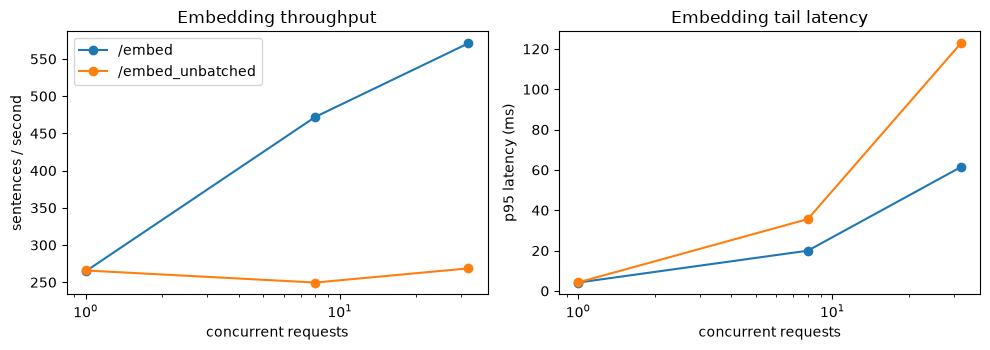

In [49]:
sentence_payloads = [{"sentences": [request_texts[i % len(request_texts)]]} for i in range(320)]
embed_rows = []
for path in ("/embed_unbatched", "/embed"):
    await load_test(embed_server.url, path, sentence_payloads[:48], concurrency=8)      # warm-up
    for concurrency in (1, 8, 32):
        n = 64 if concurrency == 1 else len(sentence_payloads)
        stats, outputs = await load_test(embed_server.url, path, sentence_payloads[:n], concurrency)
        assert stats["errors"] == 0 and all(np.asarray(o).shape == (1, 384) for o in outputs)
        embed_rows.append(stats)
embed_metrics = httpx.get(f"{embed_server.url}/metrics").text

embed_df = pd.DataFrame(embed_rows)
display(embed_df.round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for path, group in embed_df.groupby("path"):
    axes[0].plot(group["concurrency"], group["rps"], marker="o", label=path)
    axes[1].plot(group["concurrency"], group["p95_ms"], marker="o", label=path)
axes[0].set(xscale="log", xlabel="concurrent requests", ylabel="sentences / second", title="Embedding throughput")
axes[1].set(xscale="log", xlabel="concurrent requests", ylabel="p95 latency (ms)", title="Embedding tail latency")
axes[0].legend()
plt.tight_layout()
plt.show()

### Step 6 — Are the served embeddings useful? (downstream sentiment check)

We embed the training and test sentences **through the service** (64 sentences per request), pick the regularization strength `C` on a validation split carved from the training data, and touch the test set exactly once.

In [50]:
def embed_via_service(texts, chunk=64):
    with bentoml.SyncHTTPClient(embed_server.url, timeout=120) as client:
        return np.vstack([client.embed(sentences=texts[i:i + chunk]) for i in range(0, len(texts), chunk)])


with Timer() as t_embed:
    train_vectors = embed_via_service(train_texts)
    test_vectors = embed_via_service(test_texts)
print(f"embedded {len(train_texts) + len(test_texts)} sentences through the service in {t_embed.seconds:.1f}s")

fit_idx, val_idx = train_test_split(np.arange(len(train_texts)), test_size=0.2, stratify=train_labels, random_state=SEED)
val_scores = {}
for C in (0.1, 1.0, 10.0):
    probe_clf = LogisticRegression(C=C, max_iter=2000).fit(train_vectors[fit_idx], train_labels[fit_idx])
    val_scores[C] = probe_clf.score(train_vectors[val_idx], train_labels[val_idx])
best_C = max(val_scores, key=val_scores.get)
sentiment_clf = LogisticRegression(C=best_C, max_iter=2000).fit(train_vectors, train_labels)
sentiment_test_acc = sentiment_clf.score(test_vectors, test_labels)
majority_acc = max(np.mean(test_labels), 1 - np.mean(test_labels))
print("validation accuracy by C:", {c: round(s, 3) for c, s in val_scores.items()}, "→ best C =", best_C)
print(f"test accuracy {sentiment_test_acc:.3f} vs majority-class baseline {majority_acc:.3f}")

embed_server.stop()
print("embedding server stopped:", embed_server.proc.poll() is not None)

embedded 3000 sentences through the service in 4.3s
validation accuracy by C: {0.1: 0.745, 1.0: 0.743, 10.0: 0.75} → best C = 10.0
test accuracy 0.738 vs majority-class baseline 0.501


embedding server stopped: True


### Step 7 — Package it as a Bento

The build locks `torch` and `sentence-transformers` for Linux. We **don't** containerize this one by default: a PyTorch image is several GB (the default Linux x86-64 torch wheels pull in CUDA libraries) and takes many minutes to build. Set `BUILD_EMBEDDING_IMAGE=1` to try it (Docker required).

In [51]:
code, output, build_seconds = run_cli(["build", ".", "--output", "tag"], cwd=EMBED_DIR, timeout=1800)
embed_tag = built_tag(output)
if code != 0 or not embed_tag:
    print(f"❌ bentoml build failed (exit {code}) — last lines:\n{output[-1500:]}")
    embed_bento = None
else:
    embed_bento = bentoml.bentos.get(embed_tag)
    embed_reqs = (Path(embed_bento.path) / "env" / "python" / "requirements.txt").read_text().splitlines()
    print(f"built {embed_bento.tag} in {build_seconds:.1f}s | models: {[str(m.tag) for m in embed_bento.info.all_models]}")
    print("pins:", [r for r in embed_reqs if r.split("==")[0] in ("torch", "sentence-transformers", "bentoml")])

if os.environ.get("BUILD_EMBEDDING_IMAGE") == "1" and DOCKER_OK and embed_bento is not None:
    code, output, seconds = run_cli(["containerize", str(embed_bento.tag)], cwd=EMBED_DIR, timeout=3600)
    print(f"containerize exit {code} after {seconds:.0f}s:\n{output[-800:]}")
else:
    print("⏭️ Skipped containerizing the embedding Bento (opt in with BUILD_EMBEDDING_IMAGE=1; needs Docker and several GB).")

built sentence_embedder:53gzuhfp2w3nviss in 0.4s | models: ['minilm-embedder:43ywkjvp2wpo3iss']
pins: ['bentoml==1.4.39', 'sentence-transformers==6.0.1', 'torch==2.14.0']
⏭️ Skipped containerizing the embedding Bento (opt in with BUILD_EMBEDDING_IMAGE=1; needs Docker and several GB).


### Step 8 — Results and conclusions (computed from your run)

In [52]:
ep = embed_df.pivot(index="concurrency", columns="path", values=["rps", "p50_ms", "p95_ms"])
top_c = int(embed_df["concurrency"].max())
embed_speedup = ep.loc[top_c, ("rps", "/embed")] / ep.loc[top_c, ("rps", "/embed_unbatched")]
embed_p95_ratio = ep.loc[top_c, ("p95_ms", "/embed_unbatched")] / ep.loc[top_c, ("p95_ms", "/embed")]
quiet_delta = ep.loc[1, ("p50_ms", "/embed")] - ep.loc[1, ("p50_ms", "/embed_unbatched")]
avg_embed_batch = mean_batch_size(embed_metrics, "embed")

print(f"1. At {top_c} concurrent users, adaptive batching served {embed_speedup:.1f}× more sentences/s "
      f"({ep.loc[top_c, ('rps', '/embed_unbatched')]:.0f} → {ep.loc[top_c, ('rps', '/embed')]:.0f}) "
      f"and p95 latency was {embed_p95_ratio:.1f}× {'lower' if embed_p95_ratio > 1 else 'higher'}.")
print(f"2. With one user at a time, batching changed median latency by {quiet_delta:+.1f} ms — "
      f"{'negligible' if abs(quiet_delta) < 5 else 'noticeable'} at low load.")
print(f"3. The model ran on {avg_embed_batch:.1f} sentences per call on average (all load levels, incl. warm-up "
      f"and the 64-sentence client chunks of step 6).")
print(f"4. Served embeddings match local ones (max diff {np.abs(served_vectors - local_vectors).max():.1e}) and a linear "
      f"classifier on them reaches {sentiment_test_acc:.1%} test accuracy vs {majority_acc:.1%} for always guessing the majority class.")
if embed_bento is not None:
    print(f"5. Packaged as {embed_bento.tag}, pinned to model {embed_bento.info.all_models[0].tag}.")
verdict = "worth enabling" if embed_speedup > 1.2 else "not clearly helpful on this machine"
print(f"→ Verdict for this CPU-only setup: adaptive batching is {verdict} for concurrent embedding traffic.")

1. At 32 concurrent users, adaptive batching served 2.1× more sentences/s (269 → 571) and p95 latency was 2.0× lower.
2. With one user at a time, batching changed median latency by -0.0 ms — negligible at low load.
3. The model ran on 4.3 sentences per call on average (all load levels, incl. warm-up and the 64-sentence client chunks of step 6).
4. Served embeddings match local ones (max diff 0.0e+00) and a linear classifier on them reaches 73.8% test accuracy vs 50.1% for always guessing the majority class.
5. Packaged as sentence_embedder:53gzuhfp2w3nviss, pinned to model minilm-embedder:43ywkjvp2wpo3iss.
→ Verdict for this CPU-only setup: adaptive batching is worth enabling for concurrent embedding traffic.


**Stretch goals**
1. Sweep `max_batch_size` in `[8, 16, 32, 64, 128]` at concurrency 64 and plot throughput vs p95. Where does the p95 start to climb?
2. Run with `workers=2` and `EMBED_THREADS=2` (same total cores). Is it faster than one worker with batching?
3. Add an `async def search(query: str, k: int)` API that embeds the query (via the batched endpoint, with `bentoml.depends`) and returns the top-k most similar training sentences.
4. Containerize with a CPU-only PyTorch wheel (`--index-url https://download.pytorch.org/whl/cpu` in a requirements file) and compare image sizes.

### 🗣️ How to talk about this in an interview
- "I served a sentence-transformers embedding model with BentoML, loaded once per worker from a versioned model store, with a batchable API that takes a list of sentences."
- "I load-tested it with concurrent single-sentence requests and measured throughput and p95 with and without adaptive batching. On a CPU-only laptop, batching gave the speed-up printed above at 32 concurrent users with little cost at low load."
- "I verified correctness end-to-end: served vectors matched local vectors to 1e-4, and a logistic-regression probe on served embeddings beat the majority baseline, with C chosen on a validation split and the test set used once."
- "I packaged it as a Bento with locked `torch` and `sentence-transformers` versions and a pinned model tag, so the container is reproducible. I'd use CPU-only wheels or a GPU base image depending on the target."
- "In production I'd scale replicas on in-flight requests, set `max_latency_ms` from the SLO, and watch the batch-size histogram and p95 in Prometheus."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What does a model-serving framework like BentoML give you that plain FastAPI doesn't?**

<details><summary>Show answer</summary>

- **30-second answer:** Request batching, a versioned model store, reproducible packaging (locked dependencies, generated Dockerfile, exact model versions), multi-model composition where each part scales separately, and per-service worker/resource configuration. Health checks and Prometheus metrics come built in.
- **Go deeper:** BentoML is itself an ASGI (Starlette/uvicorn) app, so the HTTP layer is similar to FastAPI; the value is the ML-specific layer. For a light model with low traffic, FastAPI is perfectly fine and simpler.
- **❌ Common wrong answer:** "BentoML is faster than FastAPI." The HTTP stack is comparable. Throughput gains come from *batching* and process layout, which you could also build yourself.

</details>

**Q2. Explain adaptive (dynamic) batching. What do `max_batch_size` and `max_latency_ms` control, and what's the trade-off?**

<details><summary>Show answer</summary>

- **30-second answer:** The server queues requests that arrive close together and runs the model once on the whole group. `max_batch_size` caps items per call (a memory limit); `max_latency_ms` caps the total time a request may spend queueing plus executing. The trade-off: much higher throughput and usually lower tail latency under load, at the cost of a small waiting delay at low load.
- **Go deeper:** BentoML's dispatcher is *adaptive*: it models batch execution time and decides how long it can afford to wait. Requests that can't meet the budget get HTTP 503. Size limits come from memory (GPU RAM, padded sequence length); latency budgets come from the SLO.
- **❌ Common wrong answer:** "Batching always adds latency." Under concurrent load it usually *reduces* p95, because requests stop queueing behind one-item model calls.

</details>

**Q3. When does batching NOT help?**

<details><summary>Show answer</summary>

- **30-second answer:** When traffic is low (nothing to batch with), when the model's cost is purely per-item with no fixed overhead, when clients already send big batches, or when inputs vary wildly in size, so padding wastes compute.
- **Go deeper:** For autoregressive LLM generation, request-level batching is a poor fit because sequences finish at different times. LLM servers use **continuous (iteration-level) batching** (Orca, vLLM), adding and removing sequences at every decoding step.
- **❌ Common wrong answer:** "Just set `max_batch_size` as large as possible." Large batches can blow the latency budget and GPU memory.

</details>

**Q4. What is a Bento, and how is it different from a Docker image?**

<details><summary>Show answer</summary>

- **30-second answer:** A Bento is BentoML's versioned build artifact: service source code, references to exact model versions, locked Python dependencies, a generated Dockerfile, and the API schema. A Docker image is *built from* a Bento with `bentoml containerize`; the same Bento can also be pushed to BentoCloud.
- **Go deeper:** Models are declared with `BentoModel` class attributes so the build knows which versions to include; `latest` is resolved to a concrete tag at build time.
- **❌ Common wrong answer:** "A Bento is just a pickle of the model."

</details>

**Q5. Static vs dynamic vs continuous batching — which would you use for an LLM, and why?**

<details><summary>Show answer</summary>

- **30-second answer:** *Static*: the client or an offline job sends fixed batches. *Dynamic/adaptive*: the server groups requests arriving close in time and processes each group to completion (great for classifiers and embedders). *Continuous*: the server adds and removes sequences at every generation step. For LLMs use continuous batching (vLLM, TGI, TensorRT-LLM), because generation lengths differ and dynamic batching would make short answers wait for long ones.
- **Go deeper:** Continuous batching plus paged KV-cache memory (vLLM's PagedAttention) is what makes high-throughput LLM serving possible; BentoML and Ray Serve typically wrap such engines rather than batching LLM requests themselves.
- **❌ Common wrong answer:** "Use the same adaptive batching as for BERT."

</details>

**Q6. BentoML vs Ray Serve vs Triton vs KServe — when would you pick each?**

<details><summary>Show answer</summary>

- **30-second answer:** BentoML: batteries-included Python serving and packaging for a team. Ray Serve: complex Python pipelines and many models on a Ray cluster, fine-grained autoscaling, LLM serving on Ray. Triton: maximum GPU throughput for models exported to TensorRT/ONNX/TorchScript, with a C++ server and dynamic batcher. KServe: Kubernetes-native platform standardizing how many teams deploy models (often running Triton or other runtimes inside).
- **Go deeper:** They combine: KServe can run Triton; a BentoML or Ray Serve pipeline can call a Triton or vLLM backend. Choose by team skills, hardware cost, and existing platform.
- **❌ Common wrong answer:** Picking one tool as "the best" without mentioning workload, hardware, or team constraints.

</details>

### 💻 Coding

**Q7. Sketch an adaptive batcher with asyncio.**

<details><summary>Show answer</summary>

- **30-second answer:** `submit()` puts `(input, future)` on an `asyncio.Queue` and awaits the future. A background task awaits the first item, keeps taking items until `max_batch_size` or `max_wait` elapses, runs the model once in `asyncio.to_thread` on the stacked inputs, then calls `set_result` on each future with its own output row.
- **Go deeper:** Handle exceptions by failing every future in the batch; check the output count equals the input count; add per-request deadlines (reject with 503), padding for variable-length inputs, and metrics for batch size and queue time.
- **❌ Common wrong answer:** Running the model directly on the event loop (blocks every request), or polling the queue in a `while True` busy loop with `sleep(0)`.

</details>

**Q8. How do you make sure a batchable API returns the right answer to each request?**

<details><summary>Show answer</summary>

- **30-second answer:** The method must be a **row-wise function**: one output row per input row along `batch_dim`, with no aggregation across the batch. Then the framework can split outputs back in order.
- **Go deeper:** Test it: send concurrent requests and assert each response equals the unbatched prediction for its own input (as this notebook does). Watch for batch-dependent layers (BatchNorm in train mode) and padding that changes results.
- **❌ Common wrong answer:** "The framework handles that automatically." It splits whatever you return, and a mean over the batch comes back as HTTP 200 with wrong answers.

</details>

### 🐛 Debugging Scenarios

**Q9. After enabling batching, clients start getting HTTP 503 errors under load. Why, and how do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** The latency budget (`max_latency_ms`) is too small for the model's execution time plus queueing, so the dispatcher rejects requests it can't finish in time. Raise the budget to match the SLO, reduce `max_batch_size`, or add capacity (workers/replicas/GPU).
- **Go deeper:** Compare the budget with measured batch latency (profile batch sizes offline). Check `/metrics` for batch sizes and queue time, and check whether load simply exceeds capacity, in which case autoscaling is the fix.
- **❌ Common wrong answer:** "503 means the server crashed — restart it."

</details>

**Q10. You enabled batching, but throughput didn't improve. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Is there concurrency to batch (a load test with one client at a time can't batch)? What batch sizes does `/metrics` report? Is the load generator itself the bottleneck? Does the model have fixed per-call overhead to amortize, or is the time dominated by pre/post-processing outside the batched method?
- **Go deeper:** Profile batch-size vs latency offline; move tokenization/preprocessing into the batched call or a separate service; for CPU models check thread settings (`torch.set_num_threads`) so workers don't oversubscribe cores.
- **❌ Common wrong answer:** "Increase `max_batch_size`" without measuring what batch sizes actually form.

</details>

**Q11. The container builds fine but crashes at startup with "model not found". What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** The service loaded the model by string tag inside `__init__` instead of declaring it as a `bentoml.models.BentoModel(...)` class attribute, so `bentoml build` never recorded or packaged it. It worked locally only because the model was in the laptop's store.
- **Go deeper:** Check `bento.info.all_models` (or `bento.yaml`) after building; add a CI step that runs the container and hits `/readyz` before releasing.
- **❌ Common wrong answer:** "Mount the laptop's `~/bentoml` folder into the container."

</details>

### 🏗️ Design

**Q12. Design the serving layer for an embedding model: 2,000 requests/s, p95 < 100 ms, GPUs available.**

<details><summary>Show answer</summary>

- **30-second answer:** Profile latency vs batch size on the GPU; pick the largest batch whose latency plus a small wait fits well under 100 ms; compute per-replica throughput; replicas = peak load ÷ (throughput × ~0.7 headroom). Run adaptive batching per replica, autoscale on in-flight requests, cache repeated inputs, and keep tokenization efficient (inside the batched call or a CPU service).
- **Go deeper:** Add request timeouts and load shedding (503/429) instead of unbounded queues; versioned models with canary rollout; dashboards for p95, batch size, GPU utilization, and queue time; load tests in CI; use ONNX/TensorRT or Triton if GPU cost dominates.
- **❌ Common wrong answer:** "Put it behind FastAPI with 32 uvicorn workers on one GPU" — that multiplies GPU memory and destroys batching.

</details>

**Q13. How do you roll out a new model version safely?**

<details><summary>Show answer</summary>

- **30-second answer:** Save it as a new immutable version, build a new Bento/image tag, deploy it as a **canary** (a small % of traffic) or in **shadow** mode (receives copies of requests, responses ignored), compare latency, error rate, and prediction/business metrics, then ramp up. Roll back by redeploying the previous tag.
- **Go deeper:** Keep the input schema backward compatible (or version the API); log model version with every prediction; automate the comparison and rollback criteria.
- **❌ Common wrong answer:** "Overwrite the model file on the server and restart."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** A request to a BentoML API fails Pydantic validation (e.g. 2 features instead of 30). Which HTTP status code comes back: 400, 422, or 500?
<details><summary>Answer</summary>

**400** — see section 4. (FastAPI returns 422 for the same situation.)
</details>

**2.** You call `bentoml.sklearn.save_model("cancer_rf", model)` twice. How many versions does `bentoml.models.list("cancer_rf")` show, and which one is `cancer_rf:latest`?
<details><summary>Answer</summary>

**Two** immutable versions; `latest` is the one saved **second** (section 2 checks `latest.tag == v2.tag`).
</details>

**3.** Using your `simulate_batches` from Exercise 4: `simulate_batches([0, 5, 30, 31], max_batch_size=8, max_wait_ms=10)`?
<details><summary>Answer</summary>

`[2, 2]` — 0 and 5 fall in the first 10 ms window; 30 opens a new window and 31 joins it.
</details>

**4.** A batchable API returns `probs.mean(keepdims=True)`. Under concurrent load, what do clients see?
<details><summary>Answer</summary>

Mostly **HTTP 200 with wrong answers**: one request gets the batch mean, the others get empty lists (Pitfall 2). No error is raised.
</details>

**5.** Which built-in endpoint should a Kubernetes **readiness** probe call on a BentoML container?
<details><summary>Answer</summary>

**`/readyz`** (and liveness uses `/livez`). Our `BentoServer` helper waits on `/readyz` too.
</details>

## 📚 Resources

### 📖 Official Docs
- [BentoML documentation](https://docs.bentoml.com/en/latest/) — start here
- [Create online API Services](https://docs.bentoml.com/en/latest/build-with-bentoml/services.html) — `@bentoml.service`, `@bentoml.api`, service configuration
- [Adaptive batching](https://docs.bentoml.com/en/latest/get-started/adaptive-batching.html) — `batchable`, `batch_dim`, `max_batch_size`, `max_latency_ms`
- [Load and manage models](https://docs.bentoml.com/en/latest/build-with-bentoml/model-loading-and-management.html) — the model store and `BentoModel`
- [Run distributed Services](https://docs.bentoml.com/en/latest/build-with-bentoml/distributed-services.html) — `bentoml.depends`
- [Call an API endpoint](https://docs.bentoml.com/en/latest/build-with-bentoml/clients.html) — `SyncHTTPClient` / `AsyncHTTPClient`
- [Define input and output types](https://docs.bentoml.com/en/latest/build-with-bentoml/iotypes.html) — NumPy, pandas, files, validators
- [Packaging for deployment](https://docs.bentoml.com/en/latest/get-started/packaging-for-deployment.html) — `bentoml build`, runtime images, containerize
- [Metrics](https://docs.bentoml.com/en/latest/build-with-bentoml/observability/metrics.html) — the Prometheus metrics used in this notebook

### 🎥 Videos
- [The Full Stack — Lecture 05: Deployment (FSDL 2022)](https://www.youtube.com/watch?v=W3hKjXg7fXM) (57 min) — framework-independent: model services, batching, GPUs, and when to reach for a serving framework
- [Krish Naik — BentoML Tutorial: Build Production Grade AI Applications](https://www.youtube.com/watch?v=i_FtfdOKa2M) (29 min) — end-to-end walkthrough. It uses the **pre-1.2 API** (`bentoml.Service`, runners), so spot the differences from this notebook
- [Valerio Velardo (The Sound of AI) — How to Deploy ML Models in Production with BentoML](https://www.youtube.com/watch?v=HHkmfI_yncc) (34 min) — clear explanation of the model store, Bentos, and containerization (older API, same concepts)
- [Anyscale — Fast LLM Serving with vLLM and PagedAttention](https://www.youtube.com/watch?v=5ZlavKF_98U) (32 min) — the next step after adaptive batching: continuous batching for LLMs

### 📄 Papers
- [Clipper: A Low-Latency Online Prediction Serving System (NSDI 2017)](https://arxiv.org/abs/1612.03079) — adaptive batching under a latency SLO, the idea behind these dispatchers
- [Orca: A Distributed Serving System for Transformer-Based Generative Models (OSDI 2022)](https://www.usenix.org/conference/osdi22/presentation/yu) — iteration-level (continuous) batching
- [Efficient Memory Management for Large Language Model Serving with PagedAttention (vLLM)](https://arxiv.org/abs/2309.06180)
- [The Tail at Scale (Dean & Barroso, 2013)](https://research.google/pubs/the-tail-at-scale/) — why p99 latency matters in distributed services

### 📘 Books & Courses
- [Full Stack Deep Learning — Lecture 5: Deployment](https://fullstackdeeplearning.com/course/2022/lecture-5-deployment/) — notes for the video above
- [Made With ML — Model Serving](https://madewithml.com/courses/mlops/serving/) — free MLOps course chapter on serving (uses Ray Serve, a good bridge to the next notebook)
- [DTU MLOps — M25 ML deployment](https://skaftenicki.github.io/dtu_mlops/s7_deployment/ml_deployment/) — free university course module comparing deployment tools

### 🏋️ Practice
- [BentoML examples on GitHub](https://github.com/bentoml/BentoML/tree/main/examples) — services for LLMs, diffusion, embeddings, and more to read and run
- [Locust documentation](https://docs.locust.io/en/stable/) — write real load tests for the services you build
- [NVIDIA Triton — Batchers](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/user_guide/batcher.html) — compare Triton's dynamic batcher settings with BentoML's

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Model store | immutable, versioned models + metadata | `bentoml.sklearn.save_model`, `bentoml.models.get/list/create`, `name:latest` |
| Service | a class whose methods are HTTP endpoints | `@bentoml.service(workers=, threads=, traffic=, resources=, image=)` |
| Typed APIs | validation + OpenAPI from type hints | `@bentoml.api`, Pydantic models, `np.ndarray` + `Shape`/`DType`, `pd.DataFrame` |
| Model declaration | load once, package the exact version | `model_ref = bentoml.models.BentoModel("name:latest")` + load in `__init__` |
| Serving | local HTTP server | `bentoml serve module:Class --port 3000`; `/livez`, `/readyz`, `/metrics` |
| Clients | call from Python | `bentoml.SyncHTTPClient(url)`, `bentoml.AsyncHTTPClient(url)`; errors → 400 |
| Adaptive batching | many requests → one model call | `@bentoml.api(batchable=True, batch_dim=0, max_batch_size=, max_latency_ms=)`; row-wise outputs only |
| Async APIs | cheap concurrent waiting | `async def` + `await`; never block the event loop; `def` uses `threads` |
| Composition | multi-service pipelines | `bentoml.depends(Other)`; `self.dep.method(...)`, `await self.dep.to_async.method(...)` |
| Build | versioned artifact with locked deps | `bentofile.yaml` + `bentoml build`; `bento.info.all_models` |
| Containerize | Docker image from a Bento | `bentoml containerize tag --image-tag name:v`; serves on port 3000 |
| Load testing | trustworthy numbers | concurrent requests, warm-up, p50/p95/p99, check the client isn't the bottleneck |

## ➡️ What's Next

**[04 · Ray Serve](04_Ray_Serve.ipynb)** *(optional)* — the same serving ideas (replicas, composition, batching) on a distributed runtime, with autoscaling and LLM serving on Ray. Or skip ahead to **[11 · Polars](../11_Data_Processing/01_Polars.ipynb)** to learn fast DataFrame processing for the data pipelines that feed these models.